# Diseño e Implementación de un Sistema de Comunicación LoRa

***

##### **Asignatura:** Comunicaciones Digitales
##### **Docentes:** Corral Briones, Graciela — Ayarde, J. Martín
##### **Alumnos:** Graham, Enrique Lenox — Mamani, Franco Iván
##### **Grupo:** LenoxLegends
##### **Año de Cursado:** 2024

***

## Introducción

En este Trabajo Práctico Integrador construimos un sistema de comunicación LoRa **bloque por bloque**, partiendo del codec (bits ↔ símbolos), pasando por el modulador y los canales (AWGN + multipath), y terminando con la implementación del sistema completo sobre hardware real.

La modulación se basa en **chirps** — señales cuya frecuencia barre todo el ancho de banda durante un símbolo. A lo largo del trabajo vamos a ver por qué esa estructura resulta robusta frente al ruido y a la distorsión introducida por el canal.

Cada bloque se valida aisladamente: el codec con un round-trip de BER = 0, el waveformer + n-tuple former con SER = 0 sin canal, luego el sistema completo con canal AWGN y canal selectivo en frecuencia en simulación comparando las curvas BER vs SNR contra la Figura 1 del paper de Vangelista (2017) y finalmente el sistema sobre SDR en loopback digital y looback por antena confirmando que se recuperan los símbolos transmitidos.


## Bloques del sistema

El sistema sigue el esquema clásico de un sistema de comunicación digital (Rimoldi 2016, Cap 1):

![Diagrama de un sistema de comunicación digital](rimoldi_sistema.png)

**Transmisor:**
- **Encoder (Codec):** convierte bits en símbolos enteros.
- **Waveform Former:** convierte cada símbolo en un chirp complejo (modulación FSCM — *Frequency Shift Chirp Modulation*).

**Canal:**
- Suma **ruido AWGN** (térmico, gaussiano blanco aditivo).
- Introduce **distorsión multipath** modelada como un filtro selectivo en frecuencia.

**Receptor:**
- **n-Tuple Former:** demodula el chirp recibido, recuperando el símbolo más probable (criterio ML).
- **Decoder:** convierte el símbolo de vuelta a bits.

## Alcance del Trabajo

El trabajo se divide en dos partes complementarias:

- **Parte 1 — Implementación Software:** sistema TX/RX completo en simulación, validado contra las curvas BER/SER del paper.
- **Parte 2 — SDR (Módulo 5.1):** implementación del sistema sobre hardware real (PlutoSDR) en modo loopback.

Este notebook integra los cinco módulos del sistema:
:

| Módulo | Contenido | Bloque del sistema |
|---|---|---|
| **1 — Codec** | Codificador y decodificador bits ↔ símbolos | Encoder / Decoder |
| **2 — Waveform Former** | Generación de chirps y demodulación óptima | Waveform Former / n-Tuple Former |
| **3 — Canal AWGN** | Ruido térmico y curvas BER/SER vs SNR comparadas con la Figura 1 del paper | Canal (ruido) |
| **4 — Canal Selectivo** | Multipath con respuesta $h(nT) = \sqrt{0.8}\,\delta(nT) + \sqrt{0.2}\,\delta(nT-T)$ | Canal (distorsión) |
| **5 — SDR Loopback** | TX/RX completo sobre un único PlutoSDR (loopback digital y por antena) | Sistema completo en hardware |


**Criterio de validación (Parte 1):** las curvas BER/SER simuladas vía Monte Carlo deben aproximarse a las curvas FSCM-Flat y FSCM-Frequency-Selective publicadas en Vangelista (2017).

**Criterio de validación (Parte 2):** el sistema debe recuperar correctamente los símbolos transmitidos en loopback sobre PlutoSDR.


## Referencias

[1] **Vangelista, L.** (2017). *Frequency Shift Chirp Modulation: The LoRa Modulation*.

[2] **Rimoldi, B.** (2016). *Principles of Digital Communication: A Top-Down Approach*.

[3] **ZHENQIANG XU, SHUAI TONG, PENGJIN XIE, and JILIANG WANG** (2020). *From Demodulation to Decoding: Toward Complete LoRa
PHY Understanding and Implementation*.

[4] How To Config SDR (1).ipynb — notebook de cátedra con instrucciones de configuración del PlutoSDR.

---

## Configuración inicial — Imports y parámetros globales

### Parámetros fundamentales del sistema LoRa

| Parámetro | Símbolo | Valor | Descripción |
|---|---|---|---|
| **Spreading Factor** | $SF$ | 7 | Cantidad de bits por símbolo. Define el rango de símbolos posibles: $s \in \{0, 1, \dots, 2^{SF}-1\}$. |
| **Tamaño del alfabeto** | $M = 2^{SF}$ | 128 | Cantidad de chirps distintos = cantidad de muestras (chips) por símbolo. |
| **Ancho de banda** | $BW$ | 125 kHz | Ancho de banda del canal. |
| **Frecuencia de muestreo** | $f_s$ | $BW$ = 125 kHz | Una muestra por chip. |
| **Período de chip** | $T = 1/BW$ | 8 μs | Duración de cada chip (muestra) dentro del símbolo. |
| **Período de símbolo** | $T_s = M \cdot T$ | 1.024 ms | Duración total de un símbolo (128 chips × 8 μs). |

> Cada parámetro se profundiza en el módulo donde aparece, esta tabla es solo una referencia rápida.


### Imports y declaración de parámetros

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.image import imread 
import matplotlib.gridspec as gridspec

# === Parámetros globales del sistema LoRa ===
SF = 7              # Spreading Factor (bits por símbolo)
M  = 2 ** SF        # Tamaño del alfabeto = chips por símbolo (= 128)
BW = 125e3          # Ancho de banda [Hz]
fs = BW             # Frecuencia de muestreo [Hz]
T  = 1 / BW         # Período de chip [s]
Ts = M / BW         # Duración del símbolo [s]

print("Parámetros globales:")
print(f"  SF = {SF}")
print(f"  M  = {M} (símbolos / chips por símbolo)")
print(f"  BW = {BW/1e3:.0f} kHz")
print(f"  fs = {fs/1e3:.0f} kHz")
print(f"  T  = {T*1e6:.2f} us")
print(f"  Ts = {Ts*1e3:.3f} ms")


Parámetros globales:
  SF = 7
  M  = 128 (símbolos / chips por símbolo)
  BW = 125 kHz
  fs = 125 kHz
  T  = 8.00 us
  Ts = 1.024 ms


### Funciones de visualización

Estas funciones reciben **cualquier señal compleja** (chirp, señal post-canal, señal post-dechirp, etc.) y la visualizan. Las reutilizamos en todos los módulos del notebook — desde el chirp limpio del Módulo 2 hasta las señales ruidosas del Módulo 3 y las afectadas por el canal del Módulo 4.

In [ ]:
def plot_parte_real(signal, title):
    plt.figure(figsize=(10, 4)) 
    plt.plot(np.real(signal), color='C0', linewidth=1.2)
    plt.title(f"Parte real de {title}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)

    plt.show()

In [815]:
def plot_parte_imag(signal, title):
    plt.figure(figsize=(10, 4))
    plt.plot(np.imag(signal), color='C1', linewidth=1.2)
    plt.title(f"Parte imaginaria de {title}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)

    plt.show()

In [ ]:
def plot_frecuencia_instantanea(signal, title, OSF=1):
    fase = np.unwrap(np.angle(signal)) 
    freq_inst = np.diff(fase) / (2 * np.pi) * OSF
    plt.figure(figsize=(10, 4))
    plt.plot(freq_inst, color='C2', linewidth=1.4)
    plt.title(f"Frecuencia instantánea de {title}")
    plt.ylabel("Frecuencia normalizada f/B")
    plt.axhline(0.5, ls=':', c='gray'); plt.axhline(-0.5, ls=':', c='gray')
    ...

In [817]:
def plot_fft(signal, title, bin_marca):
    """Visualiza el espectro |FFT| de cualquier señal compleja.
    Opcionalmente marca un bin con línea roja vertical."""
    spectrum = np.fft.fft(signal)
    bins = np.arange(len(signal))

    plt.figure(figsize=(10, 4))
    plt.stem(bins, np.abs(spectrum), basefmt=' ', linefmt='C0-', markerfmt='C0o')
    if bin_marca is not None:
        plt.axvline(bin_marca, color='red', linestyle='--', alpha=0.6,
                    label=f'bin {bin_marca}')
        plt.legend()
    plt.title(f"|FFT| de {title}")
    plt.xlabel("Bin")
    plt.ylabel("|FFT|")
    plt.grid(True, alpha=0.3)
    plt.show()

# Módulo 1 — Codec (Codificador / Decodificador)

En esta primera parte implementamos el primer bloque de la capa física: el **codec**, que convierte un flujo de bits en una secuencia de símbolos enteros, y reconstruye los bits a partir de esos símbolos.

---

## 1. Conceptos básicos

Un **símbolo** es la unidad de información que se transmite por el canal en cada **período de símbolo** $T_s$ (la duración de un símbolo). Se elige de un alfabeto finito $\mathcal{H} = \{0, 1, \ldots, M-1\}$.

El **Spreading Factor (SF)** define dos cosas en LoRa:

- Cuántos bits cargo en cada símbolo: $SF$ bits.
- Tamaño del alfabeto: $M = 2^{SF}$..

### Ejemplo:

Si los bits fueran `0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1` (16 bits). Con SF=4 los agrupo de a 4 y convierto cada grupo a entero usando la **convención LSB-first del paper de Vangelista** (el primer bit del grupo pesa $2^0=1$, el último $2^{SF-1}$):

| Grupo (4 bits) | Cálculo (LSB-first) | Decimal |
|----------------|---------------------|---------|
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1000` | $1·1 + 0·2 + 0·4 + 0·8$ | 1 |
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1111` | $1·1 + 1·2 + 1·4 + 1·8$ | 15 |

**Resultado:** 16 bits → 4 símbolos `[2, 1, 2, 15]`.

## 2. Codificación: de bits a símbolos

El codificador se basa en la **ecuación (1) del paper de Vangelista (2017)**, que define formalmente cómo se mapea un bloque de SF bits a un símbolo entero:

$$s(nT_s) = \sum_{h=0}^{SF-1} w(nT_s)_h \cdot 2^h \quad \quad \quad \quad \quad \text{(1)}$$

**Variables:**

- $s(nT_s)$: símbolo resultante (entero en el rango $[0, 2^{SF}-1]$).
- $w(nT_s)_h$: bit en la posición $h$ del bloque ($w_h \in \{0, 1\}$).
- $SF$: Spreading Factor (cantidad de bits por símbolo).
- $nT_s$: instante temporal del símbolo número $n$. Es notación de tiempo discreto: $T_s$ es la duración de un símbolo, y $n$ es el índice.

**Convención LSB-first**: el bit en posición $h$ pesa $2^h$. El primer bit del bloque vale $2^0=1$, el último vale $2^{SF-1}$.

### Aplicación al ejemplo SF=4

Para el bloque $w = [0, 1, 0, 0]$ con SF=4:

| $h$ | $w_h$ | $2^h$ | $w_h \cdot 2^h$ |
|-----|-------|-------|-------------------|
| 0 | 0 | 1 | 0 |
| 1 | 1 | 2 | 2 |
| 2 | 0 | 4 | 0 |
| 3 | 0 | 8 | 0 |

Suma: $s = 0 + 2 + 0 + 0 = 2$



### `bits_to_symbols(bits, SF)` — codificador

In [943]:
def bits_to_symbols(bits, SF):
    #1-Verificamos que len(bits) sea múltiplo de SF
    if len(bits) % SF != 0:
        raise ValueError(f"len(bits)={len(bits)} no es múltiplo de SF={SF}")
    
    #2- Reshape a matriz (n_simbolos, SF)
    n_simbolos = len(bits) // SF
    matriz = bits.reshape(n_simbolos, SF)
    
    #3- Crear vector de pesos para convertir bits a símbolos
    pesos = 2 ** np.arange(SF) 
    
    # Paso 4: Producto matricial → símbolos
    simbolos = matriz @ pesos

    return simbolos

In [944]:
# --- Test unitario: bits_to_symbols (ejemplo SF=4 de la teoría) ---
bits_demo = np.array([0,1,0,0, 1,0,0,0, 0,1,0,0, 1,1,1,1])
obtenido  = bits_to_symbols(bits_demo, SF=4)
print("Test unitario: bits_to_symbols con SF=4" )
print(f"bits_demo = {bits_demo}")
print(f"bits_to_symbols obtenido {obtenido}")


Test unitario: bits_to_symbols con SF=4
bits_demo = [0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1]
bits_to_symbols obtenido [ 2  1  2 15]


## 3. Decodificación: de símbolo a bits

La fórmula del decoder no aparece en el paper de Vangelista — el paper solo define el encoder (Ec. 1). Pero es basicamente la inversa matemática de la Eq. (1):

$$w_h = \lfloor s \,/\, 2^h \rfloor \bmod 2 \;=\; (s \gg h) \,\&\, 1$$

para $h = 0, 1, \ldots, SF-1$.

**Variables:**
- $w_h$: bit recuperado en la posición $h$.
- $s$: símbolo entero del que queremos extraer los bits.
- $\bmod 2$: operador de módulo 2 (resto de la división entera por 2).


### Ejemplo con SF=4

Para verificar que el decoder es la inversa exacta del encoder, decodificamos el símbolo $s = 2$ que obtuvimos arriba (con SF=4) y comprobamos que recuperamos el bloque original $w = [0, 1, 0, 0]$:

| $h$ | $\lfloor s / 2^h \rfloor$ | $w_h = \lfloor s / 2^h \rfloor \bmod 2$ |
|-----|---------------------------|-----------------------------------------|
| 0 | $\lfloor 2/1 \rfloor = 2$ | $2 \bmod 2 = 0$ |
| 1 | $\lfloor 2/2 \rfloor = 1$ | $1 \bmod 2 = 1$ |
| 2 | $\lfloor 2/4 \rfloor = 0$ | $0 \bmod 2 = 0$ |
| 3 | $\lfloor 2/8 \rfloor = 0$ | $0 \bmod 2 = 0$ |


Bloque recuperado: $w = [0, 1, 0, 0]$  — coincide con el bloque original que entró al encoder. El round-trip cierra perfectamente.

### `symbols_to_bits(symbols, SF)` — decodificador

In [820]:
def symbols_to_bits(symbols, SF):
    #1-Reshape a matriz (n_simbolos, 1)
    symbols_col = symbols.reshape(-1, 1)

    #2- Creamos vector de shifts LBS
    shifts = np.arange(SF)

    #3- Desplazamos bits a la derecha y aplicamos AND para extraer cada bit
    matriz = (symbols_col >> shifts) & 1

    # Paso 4: Aplanar a vector 1D
    bits = matriz.flatten() 
    
    return bits

In [821]:
# --- Test unitario: symbols_to_bits (inversa exacta del anterior) ---
simbolos_demo = np.array([2, 1, 2, 15])
obtenido_bits = symbols_to_bits(simbolos_demo, SF=4)
print("Test unitario: symbols_to_bits con SF=4" )
print(f"simbolos_demo = {simbolos_demo}")
print(f"symbols_to_bits obtenido {obtenido_bits}")


Test unitario: symbols_to_bits con SF=4
simbolos_demo = [ 2  1  2 15]
symbols_to_bits obtenido [0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1]


## 4. Bit Error Rate (BER)

El **Bit Error Rate (BER)** se define como:

$$\text{BER} = \frac{\text{cantidad de bits erróneos}}{\text{cantidad de bits transmitidos}}$$

Sin canal, esperamos **BER = 0** en cualquier round-trip (encoder → decoder).


### `calcular_ber(bits_tx, bits_rx)` — métrica de errores

In [822]:
def calcular_ber(bits_tx, bits_rx):
    errores = np.sum(bits_tx != bits_rx)
    ber = errores / len(bits_tx)
    return ber

In [823]:
# --- Test unitario: calcular_ber (caso de juguete: 1 bit distinto de 4) ---
tx = np.array([0,1,0,1]); rx = np.array([0,0,0,1])
ber_demo = calcular_ber(tx, rx)
print("Test unitario: calcular_ber con 1 error en 4 bits" )
print(f"calcular_ber obtenido {ber_demo}")


Test unitario: calcular_ber con 1 error en 4 bits
calcular_ber obtenido 0.25


## 5. Test de validación del codec

In [824]:

def test_round_trip(num_bits, SF):

    print(f"TEST: {num_bits} bits aleatorios (SF={SF})")

    # Generar bits aleatorios
    
    bits_tx = np.random.randint(0, 2, num_bits)
    #bits_tx = np.array([0,1,0,0,0,0,0])
    print(f"  Bits TX: {bits_tx}")

    # Codificar
    symbols = bits_to_symbols(bits_tx, SF)
    print(f"  Símbolos: {symbols}")

    # Decodificar
    bits_rx = symbols_to_bits(symbols, SF)
    print(f"  Bits RX: {bits_rx}")

    # Calcular BER
    ber = calcular_ber(bits_tx, bits_rx)
    print(f"  BER = {ber}")
    return ber


# Tests de round-trip 
test_round_trip(num_bits=70,   SF=7);


TEST: 70 bits aleatorios (SF=7)
  Bits TX: [1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1
 1 1 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0]
  Símbolos: [ 15  91  10  62  78  95  14 115  18   9]
  Bits RX: [1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1
 1 1 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0]
  BER = 0.0


# Módulo 2 — Waveform Former y n-Tuple Former (Modulación LoRa)

La modulación que implementamos se llama **Frequency Shift Chirp Modulation (FSCM)**. Este módulo implementa los dos bloques de la capa física en el diagrama:

- **Waveform Former (TX):** convierte cada símbolo entero en un chirp complejo según la Ec. (3) de Vangelista (2017).La implementación usa su forma centrada y física, generada por rotación.
- **n-Tuple Former (RX):** recupera el símbolo a partir del chirp recibido vía *dechirp + DFT + argmax*.

Sin canal todavía, verificamos que el sistema no tenga errores (SER = 0).

---

## 1. Conceptos básicos

### Chirp y chip

Un **chirp** es una señal cuya frecuencia instantánea cambia con el tiempo. En LoRa, cada chirp tiene fase cuadrática en $k$, lo cual produce una frecuencia que crece linealmente — un *up-chirp*.

Un **chip** es una **muestra discreta** del chirp. Cada símbolo se discretiza en $M = 2^{SF}$ chips. 



## 2. Diseño del waveformer

### 2.1 La base teórica — Ecuación (3) de Vangelista

El waveformer se basa en la **ecuación (3) del paper de Vangelista (2017)**, que define el chirp para el símbolo $s$:

$$c(nT_s + kT) \;=\; \frac{1}{\sqrt{M}}\,\exp\!\left(j\,2\pi \cdot \big[(s(nT_s) + k) \bmod M\big] \cdot \frac{k}{M}\right) \qquad \text{(3)}$$

Esta es la forma simplificada de la fórmula del paper, que sale de la Ec.(2) usando $T = 1/B$ (período de chip = inverso del ancho de banda), con lo cual $kT \cdot B = k$.

**Variables:**

- $s$: símbolo a transmitir, entero en $[0, M-1]$.
- $k$: índice de chip dentro del símbolo, $k \in \{0, 1, \dots, M-1\}$.
- $M = 2^{SF}$: tamaño del alfabeto = chips por símbolo.
- $T = T_s/M = 1/BW$: período de chip.
- $1/\sqrt{M}$: normalización.

### Las 3 partes de la fórmula

1. **Normalización** $1/\sqrt{M}$: hace que la energía $E_s = \sum_k |c_s|^2 = 1$.
2. **Suma modular** $(s+k) \bmod M$: codifica el símbolo $s$ como *shift cíclico* del chirp básico ($s=0$).
3. **Rampa** $k/M$: el factor que multiplica a $(s+k) \bmod M$ produce una fase cuadrática en $k$, lo cual hace que la frecuencia instantánea crezca linealmente. Eso es lo que vuelve a la señal un "chirp".

### 2.2 De la Ec.(3) a nuestra implementación física

Partiendo de la Ec. (3), construimos el chirp con tres elecciones de diseño:

#### **Centrado en [−BW/2, BW/2]**

Vangelista (Sec. II) trabaja en $[0,BW]$, pero indica que para la señal real se centra en $[−BW/2,+BW/2]$ multiplicando la base por:

$$\exp(-j\pi k) = (-1)^k$$

que equivale a sumar $-k/2$ en la fase. **El centrado no cambia la demodulación**. Su función es ubicar el chirp **simétrico alrededor de la portadora** al transmitir en el Módulo 5 — la ocupación espectral del LoRa real.

#### **Pendiente física $k^2/(2M)$**

Usamos la pendiente con el ½, que coincide con la forma de chirp de **Xu et al. (Ec. 1)**: $\text{chirp}(t;f_0) = A\,e^{j2\pi(f_0 + \frac{B}{2T}t)t}$, donde el término $\frac{B}{2T}$ es justamente nuestra pendiente.

Es la **única pendiente donde rotar por $s$ equivale a un shift de exactamente $s/M$**: la Ec.(3) tiene pendiente $2/M$, así que rotarla por $s$ desplaza la frecuencia $2s/M$ y el símbolo caería en $2s$ (no en $s$). Con $k^2/2M$, rotar por $s$ da un shift de $s/M$ → el símbolo cae en $s$.

#### **Modulación por rotación**

El símbolo se codifica como un desplazamiento cíclico temporal del chirp de referencia: rotar un chirp de pendiente física $k^2/(2M)$ produce otro chirp con la misma pendiente pero desplazado en frecuencia — exactamente lo que hace la Ec.(3) con el término $(s+k) \bmod M$.

### 2.3 El chirp de referencia implementado

$$c_{\text{ref}}(k) = \frac{1}{\sqrt{M}}\,\exp\!\left(j\,2\pi \cdot \left[\frac{k^2}{2M}-\frac{k}{2}\right]\right)$$

Entonces el chirp para el símbolo $s$ se obtiene rotando el chirp de referencia:
$$c_s(k) = c_{\text{ref}}((k+s) \bmod M)$$

### `simbolo_a_chirp(s, SF)` — waveformer (TX)

In [ ]:
def simbolo_a_chirp(s, SF, OSF=1):
    #1- Muestras totales (oversampleadas)
    Mo = 2 ** SF * OSF

    #2- Chirp de REFERENCIA: up-chirp centrado en 0 Hz (símbolo 0).
    #   Barre de -BW/2 a +BW/2 una sola vez.
    #   El término k**2/(2M) da la pendiente física; el -0.5*k centra la banda en 0 Hz
#   (equivale a multiplicar por (-1)^k, que desplaza el espectro media banda).
    k   = np.arange(Mo)
    arg = (k / OSF)**2 / (2 * M) - 0.5 * (k / OSF) 
    chirp_ref = np.exp(1j * 2 * np.pi * arg)
    #3- Modular el símbolo s = desplazamiento cíclico del chirp de referencia
    #   (símbolo mayor inicia en frecuencia mayor -> roll negativo)
    shift = int(round(s * OSF))
    chirp = np.roll(chirp_ref, -shift)

    #4- Normalización
    return chirp / np.sqrt(M)


simbolo_a_chirp: largo 128 | energía 1.000000
simbolo_a_chirp: primeros 5 valores [0.08838835+3.46382422e-16j 0.08836173+2.16915864e-03j
 0.08796273+8.66357307e-03j 0.0862407 +1.93659966e-02j
 0.08166019+3.38247563e-02j]


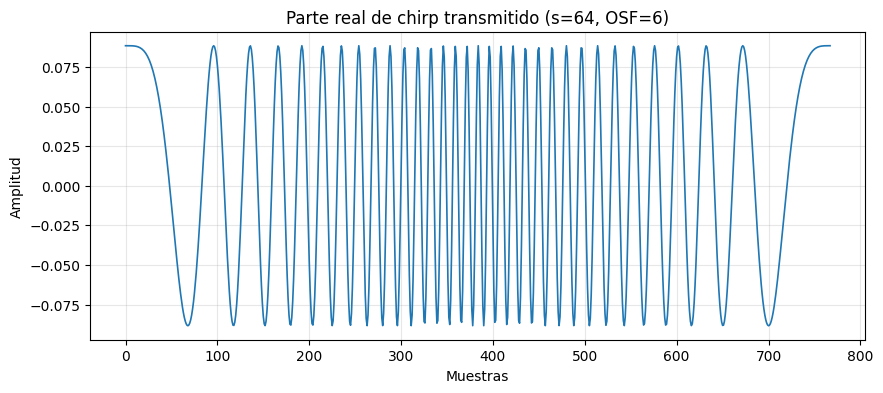

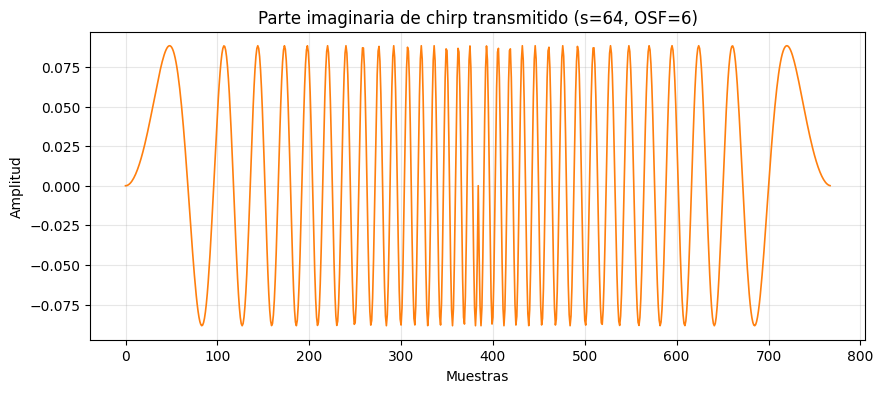

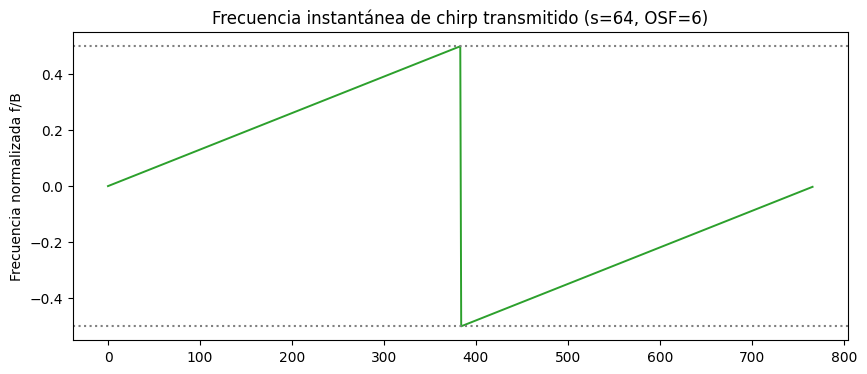

In [922]:
# --- Test unitario: simbolo_a_chirp ---
s = 64
c = simbolo_a_chirp(s, SF)         # crítico (M muestras): para el test
energia = np.sum(np.abs(c)**2)
print(f"simbolo_a_chirp: largo {len(c)} | energía {energia:.6f}")   # -> energía ≈ 1.0
print(f"simbolo_a_chirp: primeros 5 valores {c[:5]}")

# === Visualización de un chirp de ejemplo ===
OSF = 6
c_os = simbolo_a_chirp(s, SF, OSF)      # oversampleado SOLO para ver la onda suave
plot_parte_real(c_os, f"chirp transmitido (s={s}, OSF={OSF})")
plot_parte_imag(c_os, f"chirp transmitido (s={s}, OSF={OSF})")
plot_frecuencia_instantanea(c_os, f"chirp transmitido (s={s}, OSF={OSF})", OSF)

## 3. Ortogonalidad de los chirps

Como vimos antes, LoRa usa un alfabeto de $M$ símbolos. A cada símbolo le corresponde una señal, y esas $M$ señales son **mutuamente ortogonales**:

$$\langle c_s, c_{s'} \rangle = \sum_{k=0}^{M-1} c_s[k] \cdot c_{s'}^*[k] = \delta_{s, s'}$$

donde $\delta_{s,s'}$ es la **delta de Kronecker** (vale 1 si $s=s'$, 0 si $s \neq s'$).

Además, cada chirp tiene energía 1 ($\langle c_s, c_s\rangle = 1$, gracias al factor $1/\sqrt{M}$ que vimos en la parte 2), así que los $M$ chirps forman una **base ortonormal**. Esa propiedad es la clave del demodulador (n-Tuple Former) y conecta directamente con el receptor óptimo de Rimoldi.

### Mini-ejemplo: SF=2 (M=4)

Para $SF=2$ tenemos 4 chirps posibles (los que genera `simbolo_a_chirp`, con $-0.354 \approx -\tfrac{1}{2\sqrt{2}}$):

| Símbolo $s$ | Chirp $c_s$ |
|---|---|
| 0 | $[\,0.5,\;\; -0.354-0.354j,\;\; -0.5,\;\; -0.354-0.354j\,]$ |
| 1 | $[\,-0.354-0.354j,\;\; -0.5,\;\; -0.354-0.354j,\;\; 0.5\,]$ |
| 2 | $[\,-0.5,\;\; -0.354-0.354j,\;\; 0.5,\;\; -0.354-0.354j\,]$ |
| 3 | $[\,-0.354-0.354j,\;\; 0.5,\;\; -0.354-0.354j,\;\; -0.5\,]$ |

Cada $c_s$ es el chirp de referencia ($c_0$) **rotado $s$ lugares** — se ve cómo el patrón se desplaza fila a fila (es la modulación por rotación de la parte 2).

**Verificación de ortogonalidad** $\langle c_0, c_1\rangle = \sum_k c_0[k]\,c_1^*[k]$:

$$\underbrace{(-0.177+0.177j)}_{k=0} + \underbrace{(0.177+0.177j)}_{k=1} + \underbrace{(0.177-0.177j)}_{k=2} + \underbrace{(-0.177-0.177j)}_{k=3} = 0 \;✓$$

(las partes reales se cancelan entre sí, y las imaginarias también)

**Verificación de energía** $\langle c_0, c_0\rangle = \sum_k |c_0[k]|^2$:

$$0.25 + 0.25 + 0.25 + 0.25 = 1$$

(las 4 muestras tienen $|c_0[k]|^2 = 0.5^2 = 0.25$)

### Verificación de Ortonormalidad de los chirps

Se calcula la matriz de correlación entre los $M$ chirps y se verifica que sea la identidad.

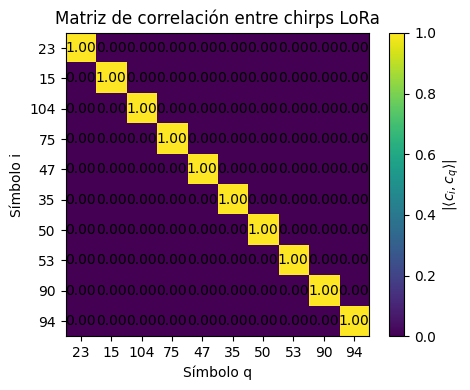

In [ ]:
def matriz_correlacion_chirps(simbolos, SF):
    
    chirps = [simbolo_a_chirp(s, SF) for s in simbolos]
    N = len(simbolos)
    G = np.zeros((N, N))

    for i in range(N):
        for q in range(N):
            G[i, q] = np.abs(np.vdot(chirps[q], chirps[i]))

    return G

#simbolos aleatorios
simbolos = np.random.randint(0, M, 10)  # 10 símbolos aleatorios entre 0 y M-1

G = matriz_correlacion_chirps(simbolos, SF)

plt.figure(figsize=(5, 4))
plt.imshow(G, origin="upper", vmin=0, vmax=1) #Upper sign

plt.colorbar(label=r"$|\langle c_i, c_q \rangle|$")
plt.xticks(np.arange(len(simbolos)), simbolos)
plt.yticks(np.arange(len(simbolos)), simbolos)

plt.title("Matriz de correlación entre chirps LoRa")
plt.xlabel("Símbolo q")
plt.ylabel("Símbolo i")

for i in range(len(simbolos)):
    for q in range(len(simbolos)):
        plt.text(q, i, f"{G[i, q]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 4. Diseño del demodulador

### El demodulador óptimo: proyectar sobre cada chirp y elegir el máximo

Vangelista (Sección III de su paper) recupera el símbolo haciendo el producto interno de la señal recibida con cada chirp:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} r[k] \cdot c_{s'}^*[k]$$

Si enviamos $c_s$ (sin ruido todavía), por ortogonalidad de la base:

$$\langle r, c_{s'}\rangle = \langle c_s, c_{s'}\rangle = \delta_{s,s'} = \begin{cases} 1 & \text{si } s'=s \\ 0 & \text{si } s'\neq s\end{cases}$$

Es decir: el producto interno es 1 solo con el chirp correcto, 0 con todos los demás. El demodulador entonces decide:

$$\hat{s} = \arg\max_{s'} \,|\langle r, c_{s'}\rangle|$$

Este criterio es el detector **ML**, que coincide con el **MAP** ya que los símbolos son equiprobables.

> **Nota:** las $M$ proyecciones son una **estadística suficiente** para decidir el símbolo. Eso significa que contienen toda la información relevante de $r$.



In [932]:
def chirp_a_simbolo_basico(rx, SF):
    M = 2 ** SF
    base = np.array([simbolo_a_chirp(q, SF) for q in range(M)])  # M plantillas (filas)
    metricas = np.abs(base.conj() @ rx)                          # parecido con cada plantilla
    return int(np.argmax(metricas))                              # elijo la que más matchea

Símbolo TX: 43
Símbolo RX: 43


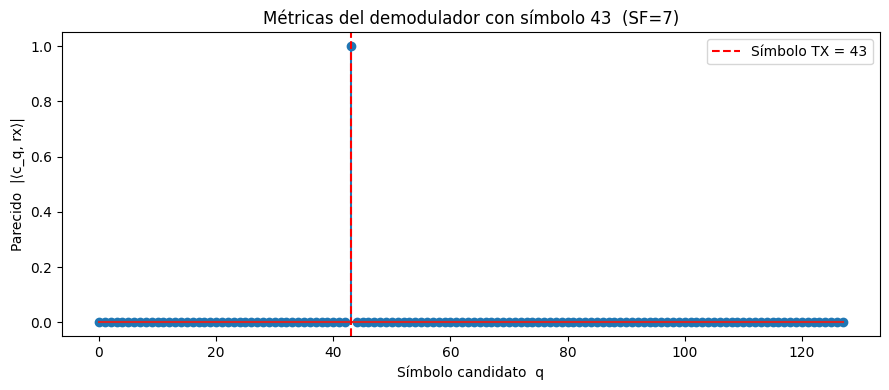

In [ ]:
# --- Test del receptor basico: un símbolo limpio ---

s_prueba = 43
rx_limpio = simbolo_a_chirp(s_prueba, SF)
s_hat = chirp_a_simbolo_basico(rx_limpio, SF)

print(f"Símbolo TX: {s_prueba}")
print(f"Símbolo RX: {s_hat}")

s_prueba = 43
rx_limpio = simbolo_a_chirp(s_prueba, SF)

# Recalculo las métricas solo para graficar (mismo cálculo que adentro de la función)
M = 2 ** SF
base = np.array([simbolo_a_chirp(q, SF) for q in range(M)])
metricas = np.abs(base.conj() @ rx_limpio)

# --- Gráfico ---
plt.figure(figsize=(9, 4))
plt.stem(range(M), metricas)
plt.axvline(s_prueba, color="red", ls="--", label=f"Símbolo TX = {s_prueba}")

plt.title(f"Métricas del demodulador con símbolo {s_prueba}  (SF={SF})")
plt.xlabel("Símbolo candidato  q")
plt.ylabel("Parecido  |⟨c_q, rx⟩|")
plt.legend()
plt.tight_layout()
plt.show()

### La simplificación práctica: down-chirp + DFT

Calcular $M$ productos internos uno por uno es costoso ($O(M^2)$). Pero si sumamos y restamos $k$ en la fase del chirp $c_{s'}^*[k]$ nos queda:

$$\frac{1}{\sqrt{M}}\,e^{-j2\pi[(s'+k)\bmod M +k-k]\,k/M} = \frac{1}{\sqrt{M}}\ e^{-j2\pi k^2/M}\cdot\,e^{-j2\pi\,([(s'+k)\bmod M]-k)\,k/M}$$

Vangelista demuestra (Sección III, ecuaciones 11-16) por análisis de casos del módulo $(s'+k) \bmod M$ que el conjugado del chirp del símbolo $s'$ se factoriza así:

$$c_{s'}^*[k] = c_0^*[k] \cdot e^{-j 2\pi s' k/M}$$

donde $c_0^*[k]$ no depende del símbolo $s'$ y $e^{-j 2\pi s' k/M}$ es una exponencial compleja pura de frecuencia $s'/M$. Reemplazando en el producto interno:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} \big(r[k] \cdot c_0^*[k]\big) \cdot e^{-j 2\pi s' k/M}$$

El lado derecho es la **DFT** de $r[k] \cdot c_0^*[k]$ evaluada en el bin $s'$. El demodulador es entonces **dechirp** ($r[k]\cdot c_0^*[k]$) + **FFT** + **argmax** del módulo:

$$\hat{s} = \arg\max_{s' \in \{0, 1, \dots, M-1\}} \big|\text{DFT}\{r \cdot c_0^*\}[s']\big|$$

Es eficiente porque la FFT calcula los $M$ productos internos para todos los $s'$ simultáneamente en $O(M \log M)$, en vez de los $O(M^2)$ de los productos uno por uno.

### De la derivación de Vangelista a nuestra implementación

La derivación de arriba es para la forma de la señal de Vangelista (Ec. 3) y da el down-chirp $c_0^*[k] = \tfrac{1}{\sqrt{M}}e^{-j2\pi k^2/M}$. Como nosotros usamos el **chirp físico centrado** (parte 2), nuestro down-chirp es:

$$c_0^*[k] = \frac{1}{\sqrt{M}}\,e^{-j2\pi\left(k^2/2M \,-\, k/2\right)}$$

que es el conjugado de nuestro chirp de referencia — exactamente el `down_chirp` de nuestro código.

La factorización $c_{s'}^*[k] = c_0^*[k]\cdot e^{-j2\pi s'k/M}$ sirve igual para el chirp físico, pero sale directo de la propiedad tiempo↔frecuencia (parte 2): como el símbolo se genera rotando $c_0$, esa rotación equivale a un shift de frecuencia $s'/M$ — sin necesidad del análisis de casos del módulo. El demodulador (dechirp + FFT + argmax) es **idéntico**; lo único que cambia es qué $c_0^*$ usás como down-chirp.

### `chirp_a_simbolo(rx, SF)` — n-tuple former + criterio ML (RX)

In [825]:
def chirp_a_simbolo(rx, SF):
    #1- Down-chirp = conjugado del chirp de referencia centrado (símbolo 0), a M muestras
    k   = np.arange(M)
    arg = k**2 / (2 * M) - 0.5 * k
    down_chirp = np.exp(-1j * 2 * np.pi * arg) / np.sqrt(M)

    #2- Dechirp: multiplicar muestra a muestra por el down-chirp
    dechirped = rx * down_chirp

    #3- DFT: calcula los M productos internos <r, c_s'> simultáneamente
    spectrum = np.fft.fft(dechirped)

    #4- Criterio de decisión ML: bin de máxima energía
    s_hat = np.argmax(np.abs(spectrum))

    return int(s_hat)


chirp_a_simbolo enviado 5 | recuperado 5


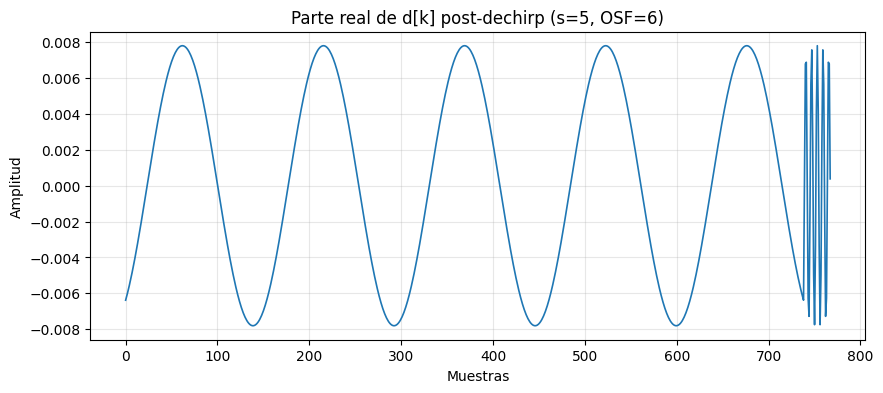

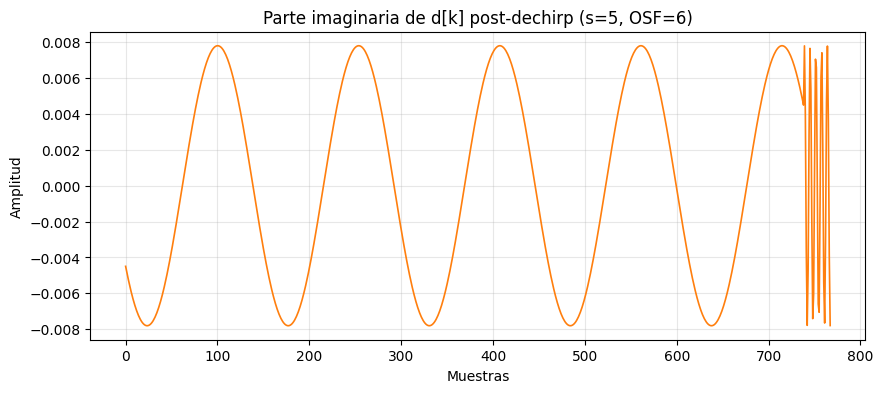

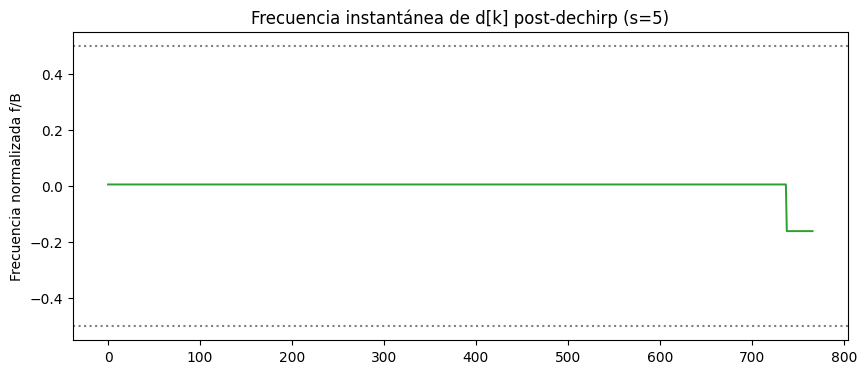

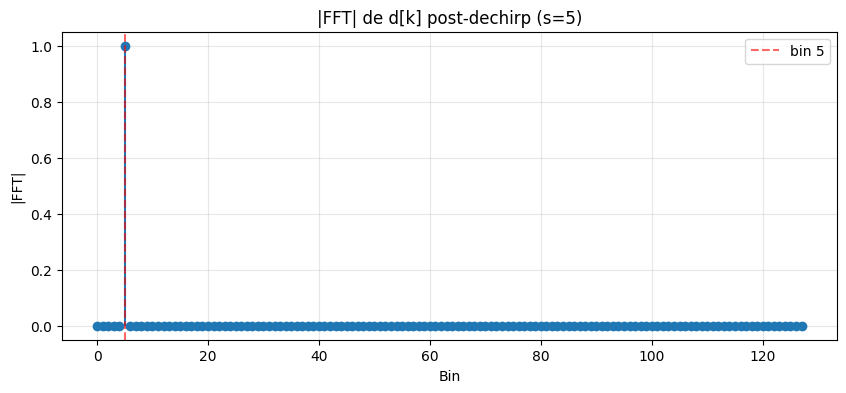

In [828]:
# --- Test unitario: chirp_a_simbolo (round-trip de un símbolo, sin canal) ---
s_prueba = 5

OSF = 6

# Generamos UNA vez, oversampleado
chirp_os = simbolo_a_chirp(s_prueba, SF, OSF)

# UN solo down-chirp (oversampleado) y UN solo dechirp
k_os = np.arange(M * OSF) / OSF
down_chirp_os = np.exp(-1j * 2 * np.pi * (k_os**2/(2*M) - 0.5*k_os)) / np.sqrt(M)
dechirped_os  = chirp_os * down_chirp_os

# Round-trip: submuestreamos a 2^SF y demodulamos
s_rec = chirp_a_simbolo(chirp_os[::OSF], SF)
print(f"chirp_a_simbolo enviado {s_prueba} | recuperado {s_rec}")

# Visual: del dechirp oversampleado
plot_parte_real(dechirped_os, f"d[k] post-dechirp (s={s_prueba}, OSF={OSF})")
plot_parte_imag(dechirped_os, f"d[k] post-dechirp (s={s_prueba}, OSF={OSF})")
plot_frecuencia_instantanea(dechirped_os, f"d[k] post-dechirp (s={s_prueba})")

# FFT: el MISMO dechirp, decimado a 2^SF → pico en el bin del símbolo
plot_fft(dechirped_os[::OSF], f"d[k] post-dechirp (s={s_prueba})", bin_marca=s_prueba)

## 5. Symbol Error Rate (SER)

El **Symbol Error Rate (SER)** se define análogo al BER, pero a nivel de **símbolo**:

$$\text{SER} = \frac{\text{cantidad de símbolos erróneos}}{\text{cantidad de símbolos transmitidos}}$$

Sin canal, esperamos SER = 0.


### `calcular_ser(simbolos_tx, simbolos_rx)` — métrica de errores

In [714]:
def calcular_ser(simbolos_tx, simbolos_rx):
    errores = np.sum(simbolos_tx != simbolos_rx)
    ser = errores / len(simbolos_tx)
    return ser

In [715]:
# --- Test unitario: calcular_ser (caso de juguete: 1 símbolo distinto de 4) ---
tx_s = np.array([0, 5, 9, 3]); rx_s = np.array([0, 5, 8, 3])
ser_demo = calcular_ser(tx_s, rx_s)
print(f"calcular_ser obtenido {ser_demo}")


calcular_ser obtenido 0.25


## 6. Test de comunicación

Prueba end-to-end del sistema TX/RX sin canal: se generan símbolos aleatorios, se modulan con `simbolo_a_chirp`, se demodulan con `chirp_a_simbolo`, y se calcula el SER.

In [716]:
# Prueba de comunicación end-to-end (sin canal)
# Generamos bits aleatorios y los convertimos a símbolos con el codec del Módulo 1
# (en vez de generar símbolos directos, así integramos los dos módulos)

N_TEST   = 1000
num_bits = N_TEST * SF
bits_tx  = np.random.randint(0, 2, num_bits)
simbolos_tx = bits_to_symbols(bits_tx, SF)
simbolos_rx = np.zeros(N_TEST, int)

# Loop de transmisión/recepción
for i in range(len(simbolos_tx)):
    s = simbolos_tx[i]
    chirp = simbolo_a_chirp(s, SF)
    simbolos_rx[i] = chirp_a_simbolo(chirp, SF)


SER = calcular_ser(simbolos_tx, simbolos_rx)
errores = int(SER * N_TEST)

print(f"Prueba de comunicación ({N_TEST} símbolos, sin canal):")
print(f"  Símbolos TX (primeros 10): {simbolos_tx[:10]}")
print(f"  Símbolos RX (primeros 10): {simbolos_rx[:10]}")
print(f"  Errores: {errores}/{N_TEST}")
print(f"  SER = {SER}")


Prueba de comunicación (1000 símbolos, sin canal):
  Símbolos TX (primeros 10): [113 115  80  26  71  45  39 104  80  67]
  Símbolos RX (primeros 10): [113 115  80  26  71  45  39 104  80  67]
  Errores: 0/1000
  SER = 0.0


# Módulo 3 — Canal con Ruido AWGN

Este módulo agrega al sistema el **canal con ruido AWGN** (*Additive White Gaussian Noise*) que se suma a la señal entre el Waveform Former y el n-Tuple Former y luego medimos cómo cambia el desempeño del segundo a medida que varía la SNR. Validamos la implementación comparando los resultados con las curvas de BER publicadas en el paper de Vangelista.

---

## 1. ¿Qué es el ruido AWGN?

**AWGN** = Additive White Gaussian Noise. Tres propiedades clave:

- **A** (Additive): se suma a la señal: $r[k] = c_s[k] + n[k]$
- **W** (White):  su densidad espectral de potencia es plana (constante) en frecuencia.
- **G** (Gaussian): cada muestra es una variable aleatoria Gaussiana.

En tiempo discreto y banda base compleja, el ruido se modela como un vector aleatorio complejo:

$n[k] = n_r[k] + j \cdot n_i[k]$

donde $n_r[k]$ y $n_i[k]$ son Gaussianas independientes de media cero y varianza $\sigma^2/2$ cada una. La varianza total compleja es entonces $\sigma^2 = \sigma_r^2 + \sigma_i^2$.

## 2. Relación entre SNR y potencia del ruido

La **SNR** (Signal-to-Noise Ratio) se define como la relación entre la potencia de la señal y la potencia del ruido:

$\text{SNR}_{\text{lineal}} = \frac{P_{\text{señal}}}{P_{\text{ruido}}}$

**Conversión:**

$\text{SNR}_{\text{dB}} = 10 \log_{10}(\text{SNR}_{\text{lineal}})$

$\text{SNR}_{\text{lineal}} = 10^{\text{SNR}_{\text{dB}}/10}$


**Potencia de la señal discreta compleja:**

$P_{\text{señal}} = \frac{1}{N} \sum_{k=0}^{N-1} |c[k]|^2$

Como el chirp tiene energía unitaria ($\sum |c[k]|^2 = 1$) y tiene $M$ muestras, $P_{\text{señal}} = 1/M$.

**Potencia del ruido**, despejando:

$P_{\text{ruido}} = \frac{P_{\text{señal}}}{\text{SNR}_{\text{lineal}}}$

Como la potencia se reparte en partes iguales, entonces la potencia total del ruido complejo es $P_{\text{ruido}}$, donde cada componente  tiene varianza $\sigma_r^2 = \sigma_i^2 = P_{\text{ruido}}/2$. Por eso:

$\sigma = \sqrt{P_{\text{ruido}}/2}$

es la desviación estándar de cada componente (real e imaginaria), esto nos sirve para generar el ruido con NumPy.

## 3. Implementación de `agregar_ruido_awgn`

La función recibe la señal y la SNR en dB, y devuelve la señal con ruido sumado.

In [ ]:
def agregar_ruido_awgn(senal, SNR_dB):
    # 1. Potencia de la señal (promedio de |señal|^2)
    P_senal = np.mean(np.abs(senal) ** 2)

    # 2. SNR lineal
    SNR_lineal = 10 ** (SNR_dB / 10)

    # 3. Potencia del ruido
    P_ruido = P_senal / SNR_lineal

    # 4. Generar ruido complejo: cada componente con varianza P_ruido/2
    sigma = np.sqrt(P_ruido / 2)
    ruido = sigma * (np.random.randn(*senal.shape) + 1j * np.random.randn(*senal.shape)) 
    
    # 5. Sumar ruido a la señal
    senal_ruidosa = senal + ruido

    return senal_ruidosa

## 4. Visualización del efecto del ruido

Generamos el chirp de un símbolo, le agregamos ruido a distintas SNR, y vemos cómo se deforma.

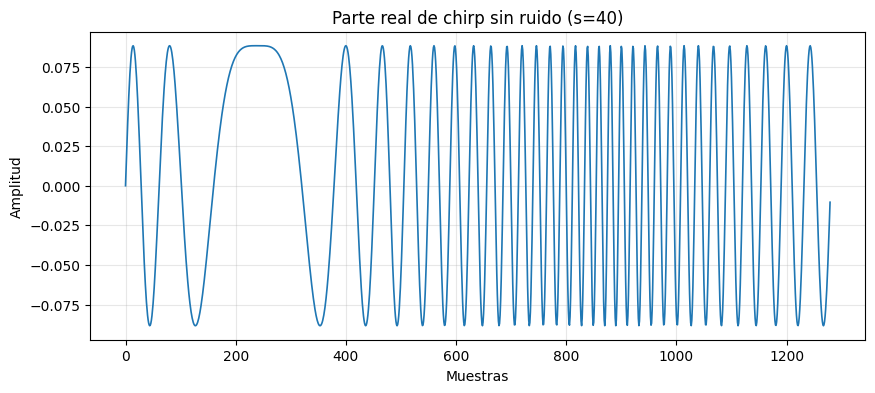

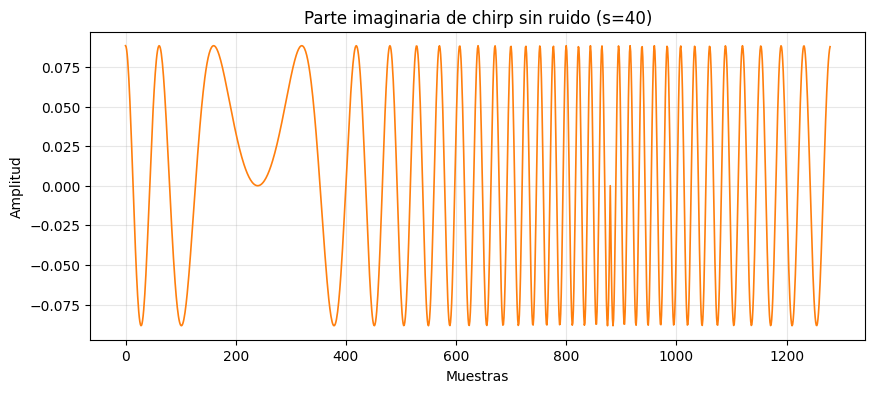

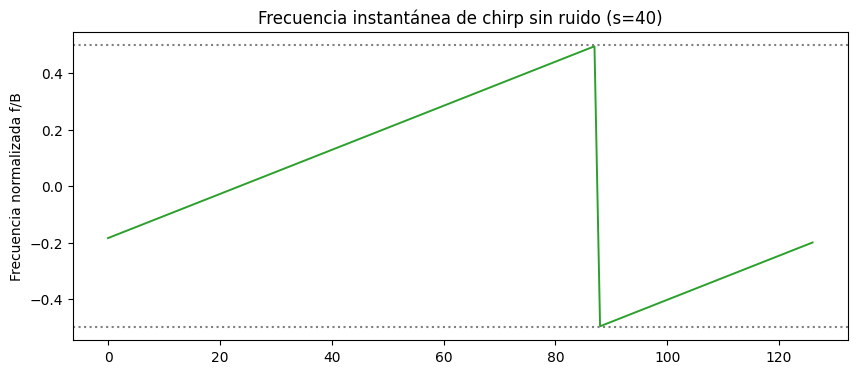

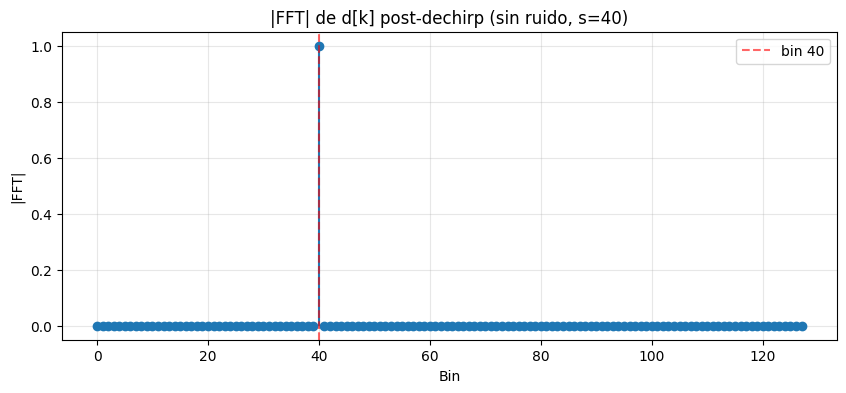

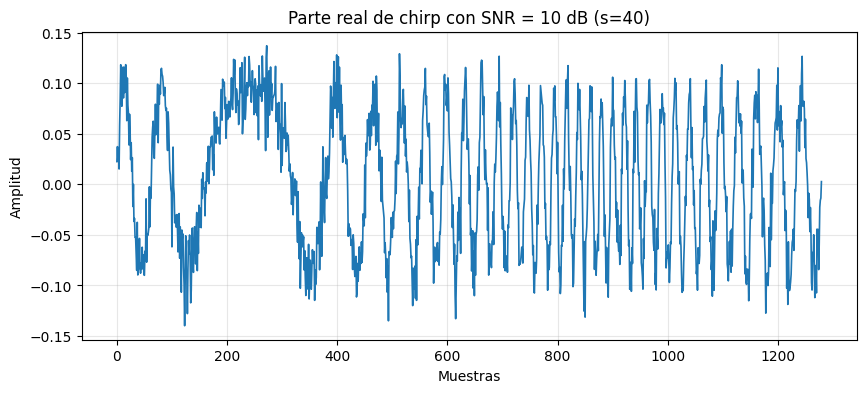

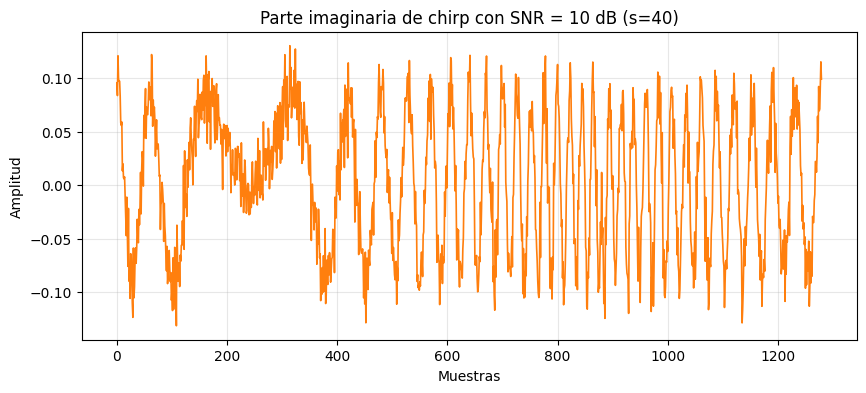

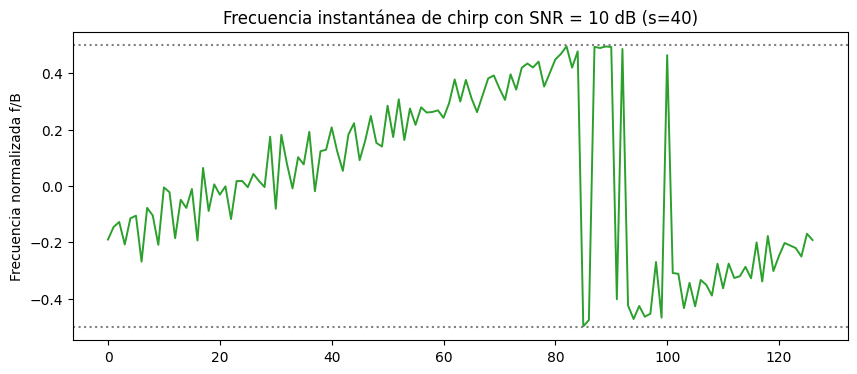

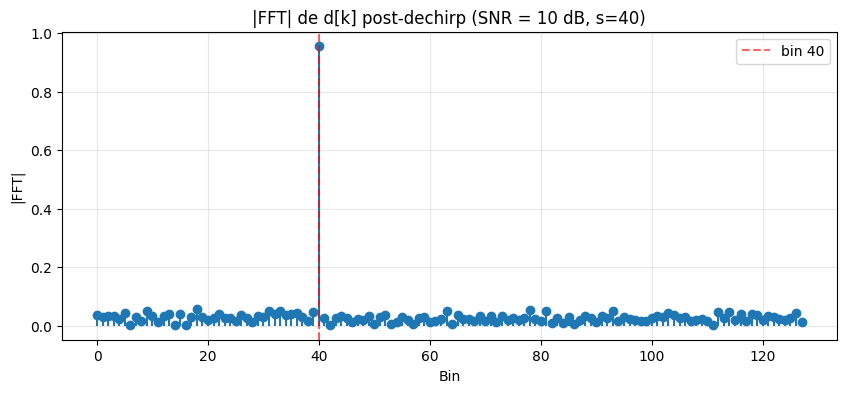

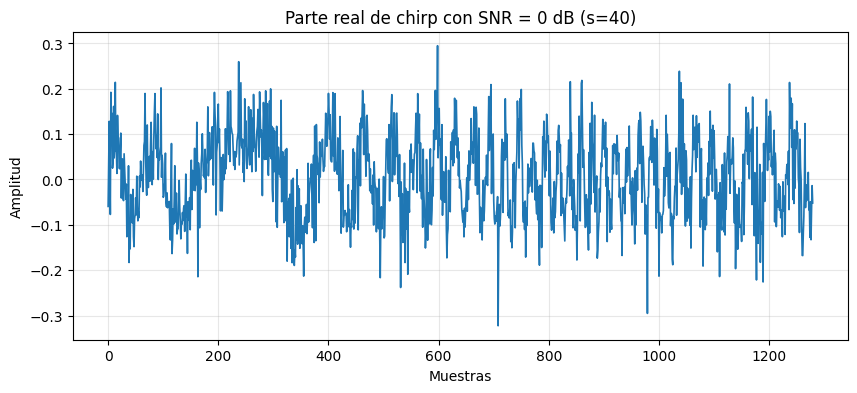

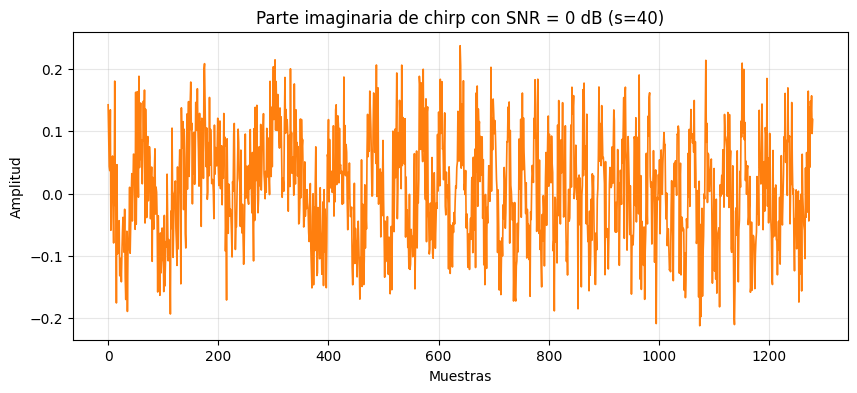

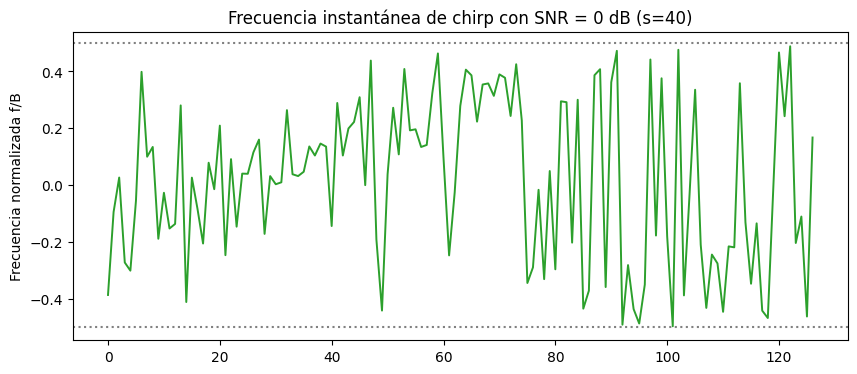

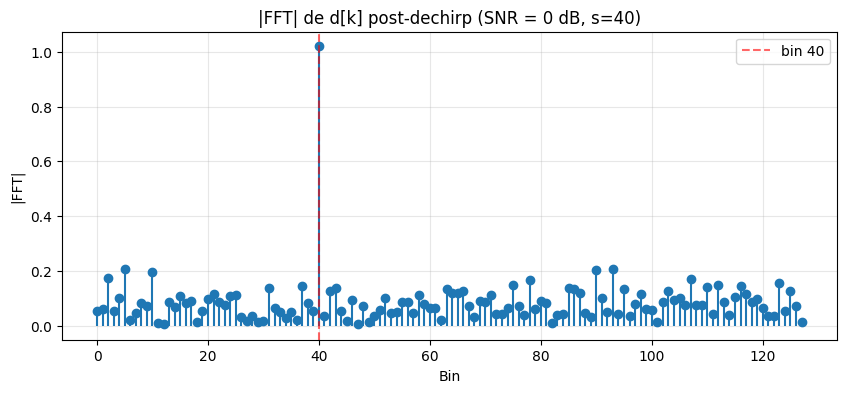

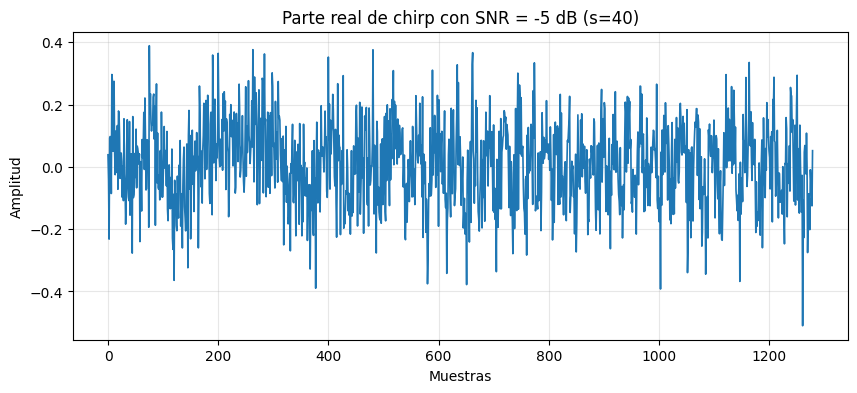

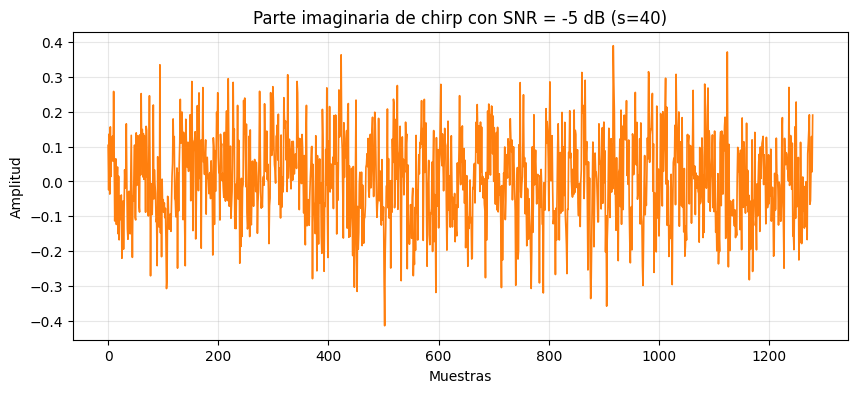

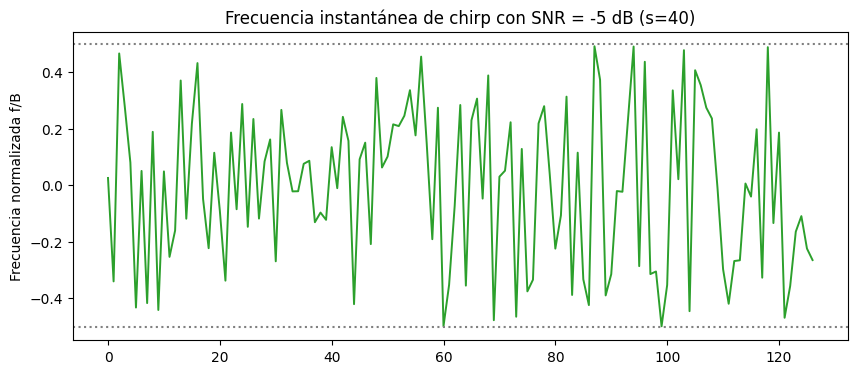

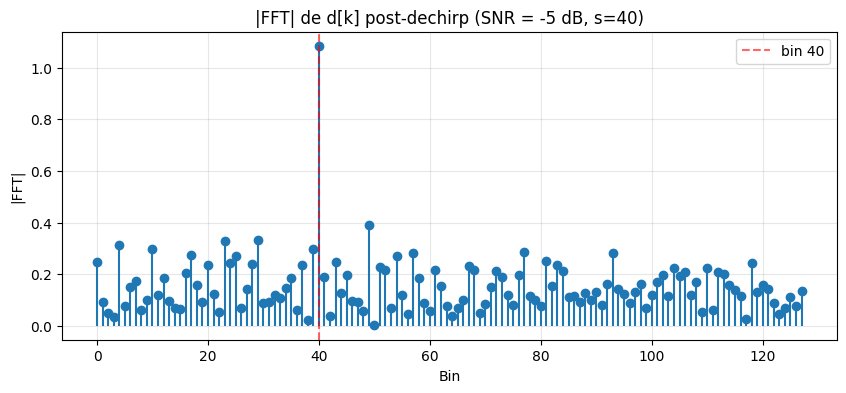

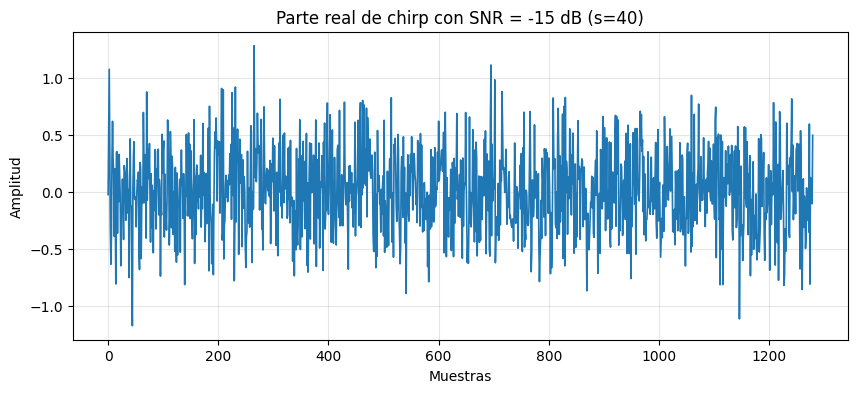

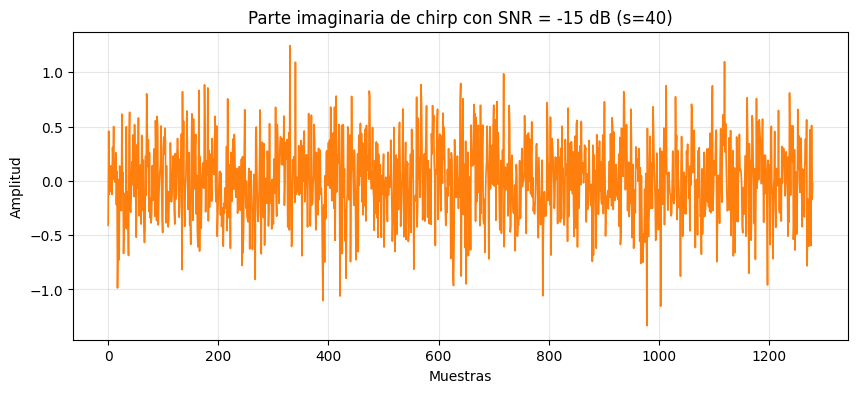

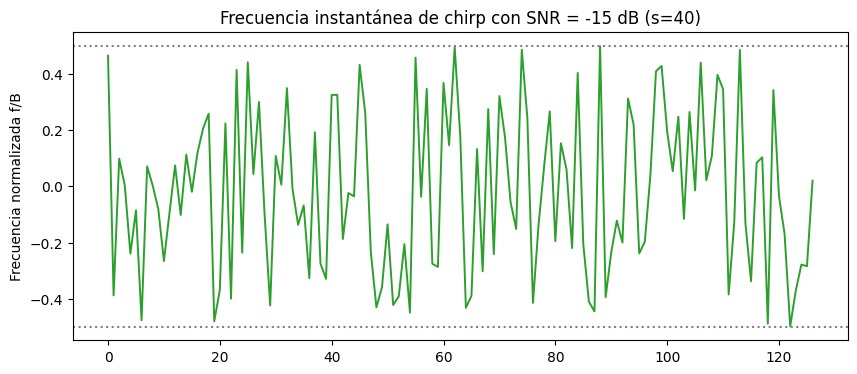

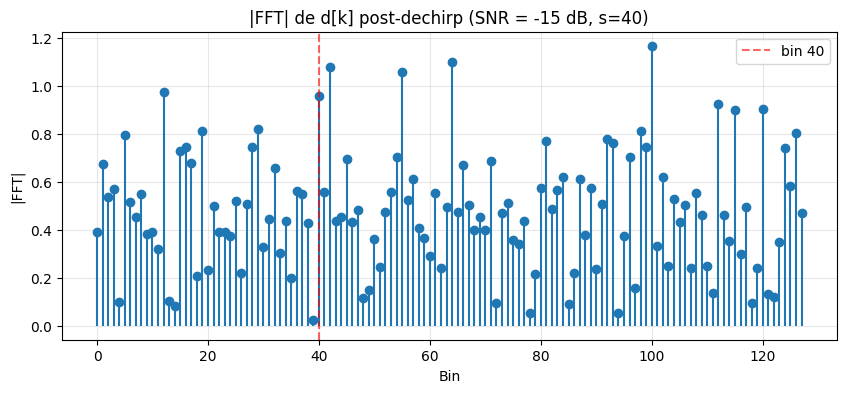

In [ ]:
# === Visualización del chirp y su dechirp: limpio y con ruido ===
s = 40
OSF = 10

# Chirp limpio (sin ruido) y oversampleado
#   _os   = oversampleado -> solo para ver la forma de onda suave
chirp_os   = simbolo_a_chirp(s, SF, OSF)

# Down-chirp y dechirp
k_os = np.arange(M * OSF) / OSF
down_chirp_os   = np.exp(-1j * 2 * np.pi * (k_os**2/(2*M) - 0.5*k_os)) / np.sqrt(M)
dechirped_os  = chirp_os * down_chirp_os

# --- Chirp limpio (sin ruido) ---
plot_parte_real(chirp_os, f"chirp sin ruido (s={s})")
plot_parte_imag(chirp_os, f"chirp sin ruido (s={s})")
plot_frecuencia_instantanea(chirp_os[::OSF], f"chirp sin ruido (s={s})")
plot_fft(dechirped_os[::OSF], f"d[k] post-dechirp (sin ruido, s={s})", bin_marca=s)

# --- Chirp con ruido a distintas SNR ---
for snr in [10, 0, -5, -15]:
    # forma de onda oversampleada (para los plots de Re/Im/frecuencia)
    ruidoso_os = agregar_ruido_awgn(chirp_os, snr)
    dechirped_ruidoso_os = ruidoso_os * down_chirp_os
    plot_parte_real(ruidoso_os, f"chirp con SNR = {snr} dB (s={s})")
    plot_parte_imag(ruidoso_os, f"chirp con SNR = {snr} dB (s={s})")
    plot_frecuencia_instantanea(ruidoso_os[::OSF], f"chirp con SNR = {snr} dB (s={s})")
    # versión a muestreo crítico (para la FFT del demod real)
    plot_fft(dechirped_ruidoso_os[::OSF], f"d[k] post-dechirp (SNR = {snr} dB, s={s})", bin_marca=s)

**Observaciones — efecto del ruido en cada dominio:**

A medida que baja la SNR podemos observar los efectos tanto en el dominio del **tiempo** como en el dominio de la **frecuencia**:

| SNR | En el tiempo (Re/Im/freq inst.) | En frecuencia (FFT post-dechirp) |
|---|---|---|
| **Sin ruido** | chirp limpio | pico aislado en bin $s$ |
| **10 dB (alta)** | chirp muy parecido al limpio |  bin dominante con otros bins ruidosos muy bajos |
| **0 dB (media)** | ruido visible | seguimos con un bin máximo pero bins ruidosos se agrandan |
| **-5 dB (baja)** | chirp enterrado en ruido visualmente | Un bin todavía domina |
| **-15 dB (muy baja)** | señal totalmente confundida con ruido | El bin maximo gana en promedio pero los bins ruidosos son muy parecidos por lo que hay errores frecuentes |

## 5. Simulación Monte Carlo de BER y SER vs SNR

Ahora medimos el desempeño completo del sistema (TX → AWGN → RX) variando la SNR.

Entonces para cada valor de SNR, transmitimos $N$ símbolos aleatorios, lo recuperamos con el demodulador, y contamos errores. Podremos observar como el BER se aproxima al SER como $\text{BER} \approx \frac{M/2}{M-1} \cdot \text{SER} \approx \frac{1}{2} \text{SER}$ para $M$ grande.

In [946]:
def simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos):

    num_bits = num_simbolos * SF

    SERs = []
    BERs = []

    print(f"{'SNR (dB)':<10} {'SER':<14} {'BER':<14} {'Errores símbolos'}") 
    print("-" * 60)

    for SNR_dB in SNR_dB_range:
        # 1. Generar bits aleatorios
        bits_tx = np.random.randint(0, 2, num_bits)

        # 2. Codificar bits -> símbolos
        simbolos_tx = bits_to_symbols(bits_tx, SF)

        # 3. Para cada símbolo: modular, agregar ruido, demodular
        simbolos_rx = np.zeros(num_simbolos, int)
        for i in range(len(simbolos_tx)):
            s = simbolos_tx[i]
            chirp = simbolo_a_chirp(s, SF)
            chirp_ruidoso = agregar_ruido_awgn(chirp, SNR_dB)
            simbolos_rx[i] = chirp_a_simbolo(chirp_ruidoso, SF)


        # 4. Decodificar símbolos -> bits
        bits_rx = symbols_to_bits(simbolos_rx, SF)

        # 5. Calcular métricas usando las funciones del sistema
        ser = calcular_ser(simbolos_tx, simbolos_rx)
        ber = calcular_ber(bits_tx, bits_rx)

        SERs.append(ser)
        BERs.append(ber)
        
        errores_simb = int(ser * num_simbolos)
        print(f"{SNR_dB:<10.1f} {ser:<16.8f} {ber:<16.8f} {errores_simb} / {num_simbolos}")
    return np.array(SERs), np.array(BERs)

# Ejecución del Monte Carlo
SNR_dB_range = np.arange(-12, -2, 1.0)
num_simbolos = 1000000

print(f"\n=== Monte Carlo: SF={SF}, BW={BW/1e3:.0f} kHz, {num_simbolos} símbolos por SNR ===\n")
SERs_simulados, BERs_simulados = simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos)



=== Monte Carlo: SF=7, BW=125 kHz, 1000000 símbolos por SNR ===

SNR (dB)   SER            BER            Errores símbolos
------------------------------------------------------------
-12.0      0.20322300       0.10243471       203223 / 1000000
-11.0      0.10113800       0.05096500       101138 / 1000000
-10.0      0.03780300       0.01899514       37803 / 1000000
-9.0       0.00997500       0.00502686       9975 / 1000000
-8.0       0.00162300       0.00081357       1623 / 1000000
-7.0       0.00013900       0.00007257       139 / 1000000
-6.0       0.00000200       0.00000100       2 / 1000000
-5.0       0.00000100       0.00000043       1 / 1000000
-4.0       0.00000000       0.00000000       0 / 1000000
-3.0       0.00000000       0.00000000       0 / 1000000


## 6. Comparación con la curva del paper Vangelista

Para validar la implementación, comparamos los resultados con las curvas de BER publicadas en el paper Vangelista, Figura 1. La imagen muestra el desempeño teórico de la modulación FSCM sobre canal Flat (AWGN) y sobre canal Selectivo en Frecuencia.

C:\Users\HP\AppData\Local\Temp\ipykernel_21084\2597518057.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


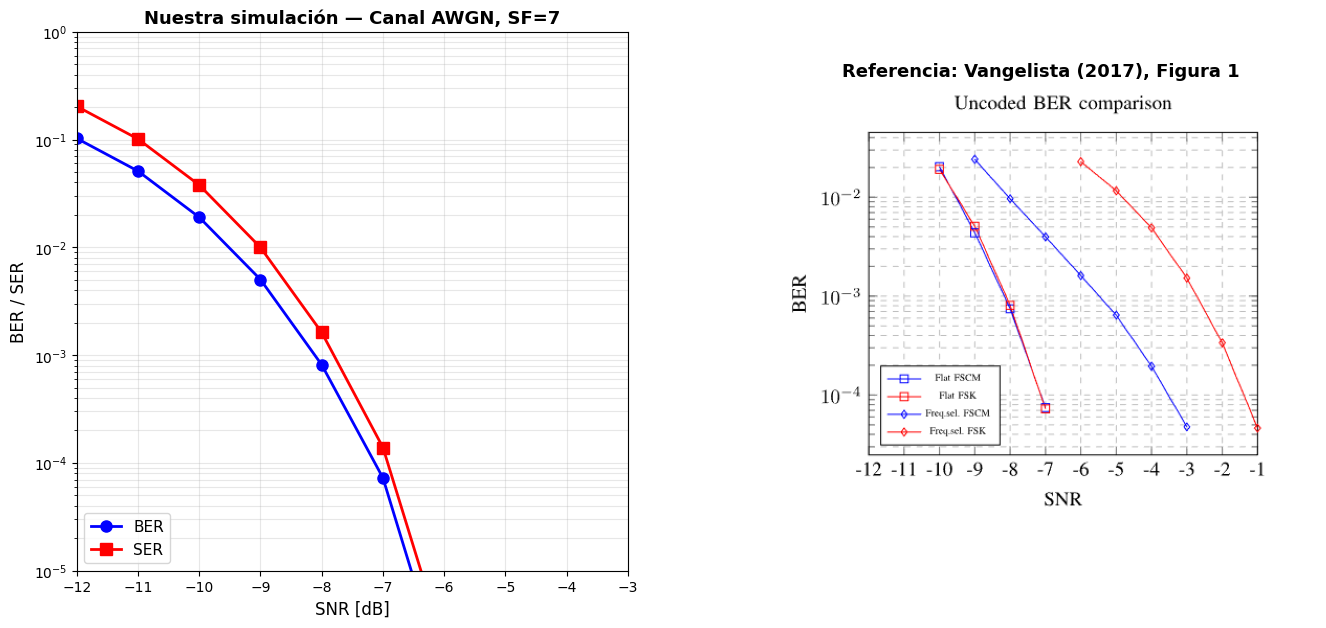

In [947]:
# Layout side-by-side: nuestra simulación vs imagen del paper
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# Panel izquierdo: nuestra simulación
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(SNR_dB_range, BERs_simulados, 'o-', label='BER', markersize=8, linewidth=2, color='blue')
ax1.semilogy(SNR_dB_range, SERs_simulados, 's-', label='SER', markersize=8, linewidth=2, color='red')
ax1.set_xlabel('SNR [dB]', fontsize=12)
ax1.set_ylabel('BER / SER', fontsize=12)
ax1.set_title(f'Nuestra simulación — Canal AWGN, SF={SF}', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11, loc='lower left')
ax1.set_xlim([SNR_dB_range[0], SNR_dB_range[-1]])
ax1.set_ylim([1e-5, 1])

# Panel derecho: imagen del paper
ax2 = fig.add_subplot(gs[0, 1])
try:
    img = imread(r'C:\Users\HP\Desktop\ComunicacionesDigitales\TP_FINAL\notebooks\TpFinal\BER.png')
    ax2.imshow(img)
    ax2.set_title('Referencia: Vangelista (2017), Figura 1', fontsize=13, fontweight='bold')
    ax2.axis('off')
except FileNotFoundError:
    ax2.text(0.5, 0.5, 'Imagen BER.png no encontrada\nen la carpeta del notebook',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.show()

### Observaciones:

**AWGN (canal plano):** nuestra curva de BER de FSCM es idéntica a la "Flat FSCM" de Vangelista, punto a punto (aprox 2·10⁻² a −10 dB, ~10⁻³ a −8 dB, ~7·10⁻⁵ a −7 dB). Tambien vemos como Vangelista compara AWGN FSCM y FSK, y podemos observar como son practicamente iguales en desempeño.

# Módulo 4 — Canal Selectivo en Frecuencia

---

## 1. ¿Qué es un canal selectivo en frecuencia?

En el anterior modulo trabajamos con un canal AWGN: agrega ruido pero no distorsiona la señal. Un canal real, suele tener **multipath** que significa que la señal llega al receptor por varios caminos físicos, cada uno con su propio delay y atenuación

Cuando esas copias se suman, el resultado depende de la frecuencia: en algunas se suman (interferencia constructiva, **+dB**) y en otras se cancelan (destructiva, **−dB**). El canal "selecciona" frecuencias.

Matemáticamente, un canal selectivo se modela como un sistema LTI con **respuesta al impulso** $h(nT)$ que tiene varias componentes (uno por camino físico). La salida del canal es la **convolución** de la señal transmitida con $h$:

$$r(nT) = (h \ast s)(nT) + w(nT)$$

donde $w$ es el ruido AWGN del Módulo 3.

## 2. La respuesta al impulso h(nT) de Vangelista

$$h(nT) = \sqrt{0.8}\,\delta(nT) + \sqrt{0.2}\,\delta(nT - T)$$

El canal *convoluciona* la señal con $h$, y convolucionar en el tiempo equivale a *multiplicar en frecuencia* ($Y = X \cdot H$). Tomamos entonces $H(f) = \text{FFT}(h)$ y su módulo al cuadrado $|H(f)|^2$, porque lo que importa es la potencia que pasa en cada frecuencia:

$$|H(f)|^2 = 1 + 0.8\cos(2\pi f T)$$

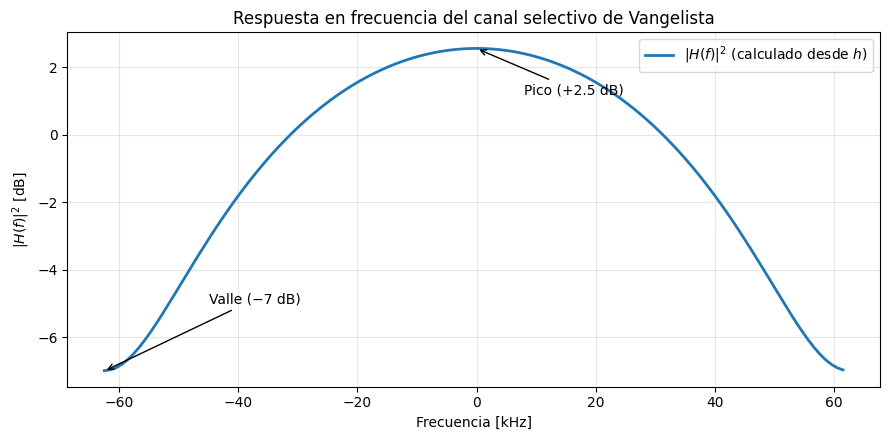

In [ ]:
# Misma h que usa agregar_canal_selectivo
h_canal = np.array([np.sqrt(0.8), np.sqrt(0.2)])

# 1) Transformada de h  -> respuesta en frecuencia
Nfft = 128
H = np.fft.fft(h_canal, Nfft)

# 2) Módulo al cuadrado -> respuesta en potencia, y en dB
H2_dB = 10 * np.log10(np.abs(H)**2)

# Eje de frecuencia en kHz (BW de LoRa = 125 kHz), centrado en 0
f = np.fft.fftshift(np.fft.fftfreq(Nfft, 1/BW)) / 1e3
H2_dB = np.fft.fftshift(H2_dB)

plt.figure(figsize=(9, 4.5))
plt.plot(f, H2_dB, lw=2, label=r'$|H(f)|^2$ (calculado desde $h$)')
plt.annotate('Pico (+2.5 dB)', xy=(0, 2.55), xytext=(8, 1.2),
             arrowprops=dict(arrowstyle='->'))
plt.annotate('Valle (−7 dB)', xy=(-62.5, -7), xytext=(-45, -5),
             arrowprops=dict(arrowstyle='->'))
plt.title('Respuesta en frecuencia del canal selectivo de Vangelista')
plt.xlabel('Frecuencia [kHz]'); plt.ylabel(r'$|H(f)|^2$ [dB]')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

## 3. Implementación de `agregar_canal_selectivo`

La función toma una señal (un chirp) y la convoluciona con $h(nT)$.

In [941]:
def agregar_canal_selectivo(senal, OSF=1):
    # Respuesta al impulso del canal selectivo
    h = np.zeros(OSF + 1)
    h[0]   = np.sqrt(0.8)   # camino directo
    h[OSF] = np.sqrt(0.2)   # eco a 1 chip = OSF muestras
    
    # Convolucionar la señal con la respuesta al impulso del canal
    return np.convolve(senal, h)[:len(senal)]

## 4. Visualización del efecto del canal selectivo

Tomamos un chirp limpio (símbolo de prueba) y lo pasamos por el canal. Vemos cómo se modifica en tiempo y cómo afecta al dechirp + FFT (que es lo que ve el receptor LoRa).

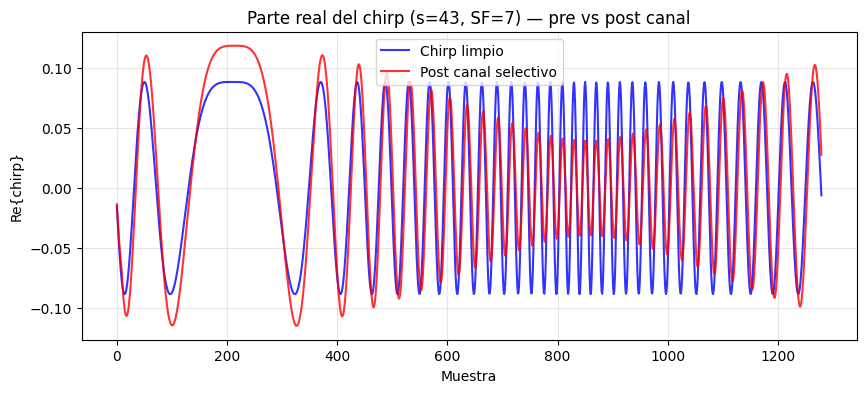

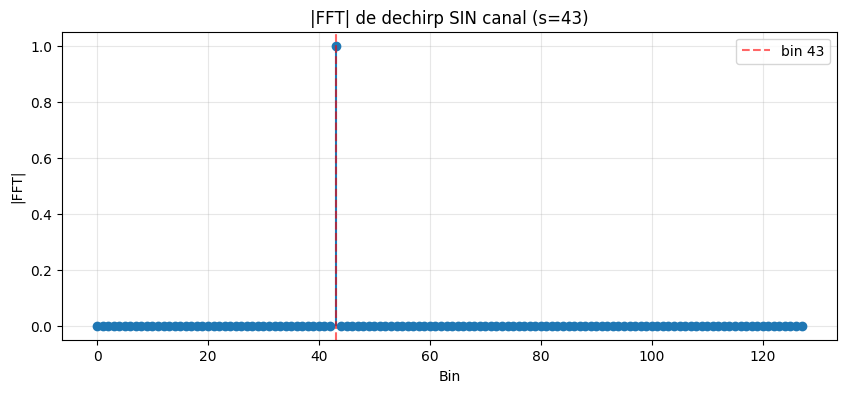

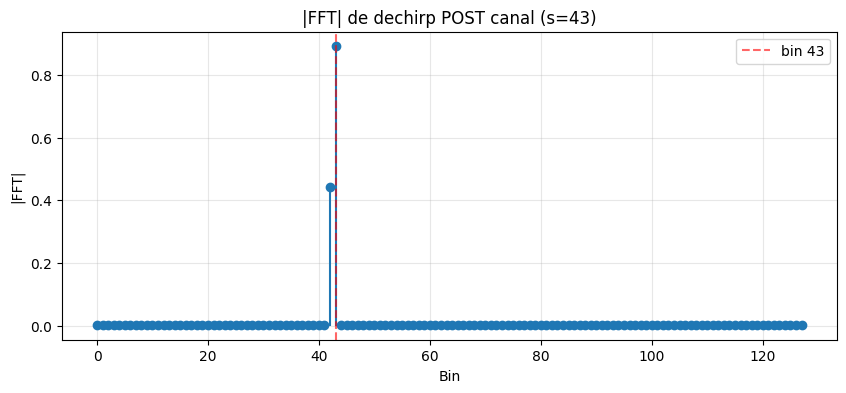

In [942]:
#--- Test unitario: simbolo_a_chirp + agregar_canal_selectivo ---

# Parámetros de la visualización
s_test = 43
OSF = 10

# Generamos el chirp oversampleado y lo pasamos por el canal selectivo
chirp_os       = simbolo_a_chirp(s_test, SF, OSF)
chirp_os_canal = agregar_canal_selectivo(chirp_os, OSF)

# --- Panel 1: forma de onda pre/post canal (oversampleada) ---
k_os = np.arange(M * OSF)          # muestras (sin /OSF)
plt.figure(figsize=(10, 4))
plt.plot(k_os, np.real(chirp_os),       'b-', label='Chirp limpio',         alpha=0.8, lw=1.5)
plt.plot(k_os, np.real(chirp_os_canal), 'r-', label='Post canal selectivo', alpha=0.8, lw=1.5)
plt.title(f'Parte real del chirp (s={s_test}, SF={SF}) — pre vs post canal')
plt.xlabel('Muestra'); plt.ylabel('Re{chirp}')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# --- Paneles 2 y 3: DECIMAR a 2^SF y FFT (lo que ve el demod) ---
down_crit = np.conj(simbolo_a_chirp(0, SF))
plot_fft(chirp_os[::OSF]       * down_crit, f'dechirp SIN canal (s={s_test})',  bin_marca=s_test)
plot_fft(chirp_os_canal[::OSF] * down_crit, f'dechirp POST canal (s={s_test})', bin_marca=s_test)

## 5. Simulación Monte Carlo de BER y SER vs SNR — con canal selectivo

Mismo loop que el Módulo 3, pero agregando el canal selectivo antes del ruido AWGN (el canal actúa sobre la señal transmitida, no sobre el ruido propio del receptor):

Procesamos **per-símbolo** (cada chirp por separado), igual que en el Módulo 3. Esta convención captura la distorsión intra-símbolo causada por el multipath; no incluye ISI entre símbolos consecutivos (con 2 componentes y delay = 1 chip sería pequeña de todos modos).

In [724]:
def simular_ber_ser_vs_snr_selectivo(SF, SNR_dB_range, num_simbolos):

    M = 2 ** SF
    num_bits = num_simbolos * SF

    SERs = []
    BERs = []

    print(f"{'SNR (dB)':<10} {'SER':<16} {'BER':<16} {'Errores símbolos'}")
    print("-" * 60)

    for SNR_dB in SNR_dB_range:
        # 1. Generar bits aleatorios
        bits_tx = np.random.randint(0, 2, size=num_bits)

        # 2. Codificar bits -> símbolos
        simbolos_tx = bits_to_symbols(bits_tx, SF)

        # 3. Para cada símbolo: modular -> canal selectivo -> AWGN -> demodular
        simbolos_rx = np.zeros(num_simbolos, dtype=int)
        for i in range(len(simbolos_tx)):
            s = simbolos_tx[i]
            chirp = simbolo_a_chirp(s, SF)
            chirp_canal = agregar_canal_selectivo(chirp)              # canal selectivo primero
            chirp_ruidoso = agregar_ruido_awgn(chirp_canal, SNR_dB)   # después AWGN
            simbolos_rx[i] = chirp_a_simbolo(chirp_ruidoso, SF)

        # 4. Decodificar símbolos -> bits
        bits_rx = symbols_to_bits(simbolos_rx, SF)

        # 5. Calcular métricas
        ser = calcular_ser(simbolos_tx, simbolos_rx)
        ber = calcular_ber(bits_tx, bits_rx)

        SERs.append(ser)
        BERs.append(ber)
        errores_sim = int(ser * num_simbolos)
        print(f"{SNR_dB:<10.1f} {ser:<14.6f} {ber:<14.6f} {errores_sim} / {num_simbolos}")

    return np.array(SERs), np.array(BERs)


# Ejecución del Monte Carlo — canal selectivo
SNR_dB_range_sel = np.arange(-12, -2, 1.0)  # mismo rango que AWGN para comparar
num_simbolos_sel = 1000000

print(f"\n=== Monte Carlo CANAL SELECTIVO: SF={SF}, BW={BW/1e3:.0f} kHz, {num_simbolos_sel} símbolos por SNR ===\n")
SERs_selectivo, BERs_selectivo = simular_ber_ser_vs_snr_selectivo(SF, SNR_dB_range_sel, num_simbolos_sel)


=== Monte Carlo CANAL SELECTIVO: SF=7, BW=125 kHz, 1000000 símbolos por SNR ===

SNR (dB)   SER              BER              Errores símbolos
------------------------------------------------------------
-12.0      0.348108       0.164715       348108 / 1000000
-11.0      0.223922       0.102384       223922 / 1000000
-10.0      0.125769       0.054014       125768 / 1000000
-9.0       0.062062       0.024091       62062 / 1000000
-8.0       0.028396       0.009638       28396 / 1000000
-7.0       0.013023       0.003945       13023 / 1000000
-6.0       0.005787       0.001638       5787 / 1000000
-5.0       0.002135       0.000612       2135 / 1000000
-4.0       0.000689       0.000199       689 / 1000000
-3.0       0.000172       0.000044       172 / 1000000


## 6. Comparación con la curva del paper Vangelista (Freq.sel. FSCM)

C:\Users\HP\AppData\Local\Temp\ipykernel_21084\1985226226.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


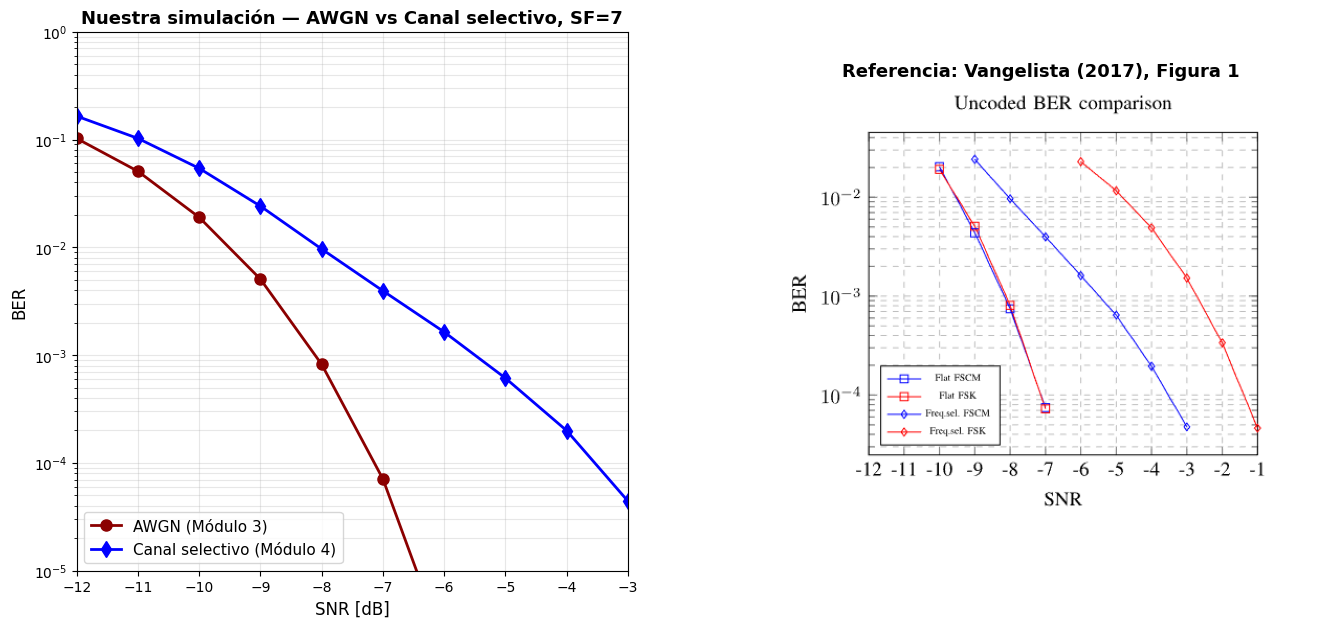

In [725]:
# Layout side-by-side: nuestras curvas vs imagen del paper
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# Panel izquierdo: nuestras curvas — AWGN vs Selectivo
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(SNR_dB_range,     BERs_simulados, 'o-', label='AWGN (Módulo 3)',            markersize=8, linewidth=2, color='darkred')
ax1.semilogy(SNR_dB_range_sel, BERs_selectivo, 'd-', label='Canal selectivo (Módulo 4)', markersize=8, linewidth=2, color='blue')
ax1.set_xlabel('SNR [dB]', fontsize=12)
ax1.set_ylabel('BER', fontsize=12)
ax1.set_title(f'Nuestra simulación — AWGN vs Canal selectivo, SF={SF}', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11, loc='lower left')
ax1.set_xlim([SNR_dB_range_sel[0], SNR_dB_range_sel[-1]])
ax1.set_ylim([1e-5, 1]) 

# Panel derecho: imagen del paper
ax2 = fig.add_subplot(gs[0, 1])
try:
    img = imread(r'.\BER.png')
    ax2.imshow(img)
    ax2.set_title('Referencia: Vangelista (2017), Figura 1', fontsize=13, fontweight='bold')
    ax2.axis('off')
except FileNotFoundError:
    ax2.text(0.5, 0.5, 'Imagen BER.png no encontrada\nen la carpeta del notebook',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.show()

### Observaciones:

**Canal selectivo:** nuestra curva es idéntica a la "Freq.sel FSCM" de Vangelista. Podemos observar que FSCM es mucho más robusto que FSK en este canal selectivo: mientras que FSK pone cada símbolo en una sola frecuencia, FSCM barre toda la banda y promedia la respuesta del canal. Por eso FSCM tiene un desempeño mucho mejor que FSK en presencia de selectividad en frecuencia.

# Módulo 5a — Integración con PlutoSDR (Loopback Digital)
---

Transmisión y detección de símbolos LoRa a través de un PlutoSDR en loopback digital (`loopback=1`): el TX se enruta al RX dentro del FPGA, sin pasar por RF. Valida la cadena completa (bits -> símbolos -> chirps -> TX -> RX -> demodulación -> bits) reutilizando las funciones de los Módulos 1–4.

El SDR trabaja oversampleado (el sample rate mínimo del Pluto, ~521 kSPS, está por encima del BW de LoRa), por lo que en RX se submuestrea a la frecuencia de muestreo del LoRa (125 kHz) antes de pasar al demodulador.

## Instalación de dependencias e imports

El PlutoSDR se controla con la librería `pyadi-iio`, la interfaz de Python de Analog Devices construida sobre `libiio`. Se instala junto con `pylibiio`. Una vez instalada, la librería se importa como `adi`.

In [726]:
#pip install pyadi-iio pylibiio
import adi
import time

## 1. Parámetros del SDR

La configuración del PlutoSDR sigue el procedimiento del notebook de cátedra *How_To_Config_SDR* [ref], que documenta cada parámetro del transceptor AD9363. Los valores se eligen para reproducir un enlace LoRa de BW = 125 kHz:

- **`Loopback`**: modo de lazo de retorno (0 = desactivado, 1 = digital, 2 = RF). En esta prueba se usa el loopback digital.
- **`TxLOFreq` / `RxLOFreq`**: frecuencia de portadora de TX y RX (banda de 915 MHz).
- **`SamplingRate`**: tasa de muestreo del conversor. Se fija en `OSF·BW`, por encima del mínimo de 521 kSPS que impone el Pluto.
- **`TxRfBw` / `RxRfBw`**: ancho de banda del filtro analógico de front-end (rango 200 kHz – 20 MHz en el AD9363). Se configura igual a `SamplingRate` para no recortar la señal.
- **`TxAtten`**: atenuación del camino de TX (controla la potencia de salida).
- **`GainControlModes` / `RxHardwareGain`**: control de ganancia del RX (AGC automático o ganancia manual).

Los rangos y el comportamiento de cada parámetro están documentados en el notebook de cátedra [[ref](<How To Config SDR (1).ipynb>)] y en el datasheet del AD9363.

In [ ]:
#------------------------------- Configuración de parámetros del SDR -------------------------------

OSF_sdr          = 8                   # oversampling (muestras por chip)
num_simbolos     = 8                   # cantidad de símbolos a transmitir
M                = 2**SF

Uri              = "ip:192.168.1.34"   # dirección del Pluto en el lab (vía VPN)
Loopback         = 1                   # 0=desactivado, 1=loopback digital, 2=retransmisor
SamplingRate     = 1e6                 # tasa de muestreo RX y TX [muestras/s] = 1 MSPS
TxLOFreq         = 915e6               # portadora del camino TX [Hz]
TxAtten          = -10                 # atenuación del camino TX, rango válido -89 a 0 [dB]
TxRfBw           = int(SamplingRate) # ancho de banda del filtro analógico TX [Hz]
tx_cyclic_buffer = True                # el buffer TX se repite en loop
RxLOFreq         = TxLOFreq            # portadora del camino RX [Hz]
GainControlModes = "slow_attack"       # AGC del RX: slow_attack, fast_attack, manual
RxHardwareGain   = 0                   # ganancia RX (solo si gain_control_mode = 'manual') [dB]
RxRfBw           = TxRfBw              # ancho de banda del filtro analógico RX [Hz]
RxBufferSize     = int(2 * num_simbolos * OSF_sdr * M)   # buffer RX, máx 2**28 [muestras]

## 2. Configuración del hardware (ADI Pluto)

Se conecta al Pluto y se cargan los parámetros definidos arriba.

In [728]:
sdr = adi.Pluto(Uri)                          # conexión al Pluto (acá se define sdr)

sdr.sample_rate             = int(SamplingRate)
sdr.tx_lo                   = int(TxLOFreq)
sdr.rx_lo                   = int(RxLOFreq)
sdr.tx_rf_bandwidth         = int(TxRfBw)
sdr.rx_rf_bandwidth         = int(RxRfBw)
sdr.tx_hardwaregain_chan0   = TxAtten
sdr.gain_control_mode_chan0 = GainControlModes
sdr.rx_hardwaregain_chan0   = RxHardwareGain
sdr.loopback                = Loopback
sdr.tx_cyclic_buffer        = tx_cyclic_buffer
sdr.rx_buffer_size          = RxBufferSize

print(f"Conectado a {sdr.uri} | sample_rate: {sdr.sample_rate/1e6:.3f} MSPS | loopback: {sdr.loopback}")

Conectado a ip:192.168.1.34 | sample_rate: 2.000 MSPS | loopback: 1


## 3. Transmisión (TX)

Se generan bits aleatorios, se codifican a símbolos con `bits_to_symbols` (Módulo 1), se convierten a chirps con `simbolo_a_chirp` (OSF=8) y se escalan a enteros (×2¹⁴) antes de transmitir ya que el PlutoSDR trabaja con enteros de 16 bits y la señal LoRa tiene amplitud máxima 1.

Transmitiendo los bits: [1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 1
 1 0 1 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0]
Símbolos a transmitir: [85 10 83  8 11 23 28 54]
Forma de onda TX: 4096 muestras, energía 8.59e+09
Transmitiendo 8 símbolos (4096 muestras)


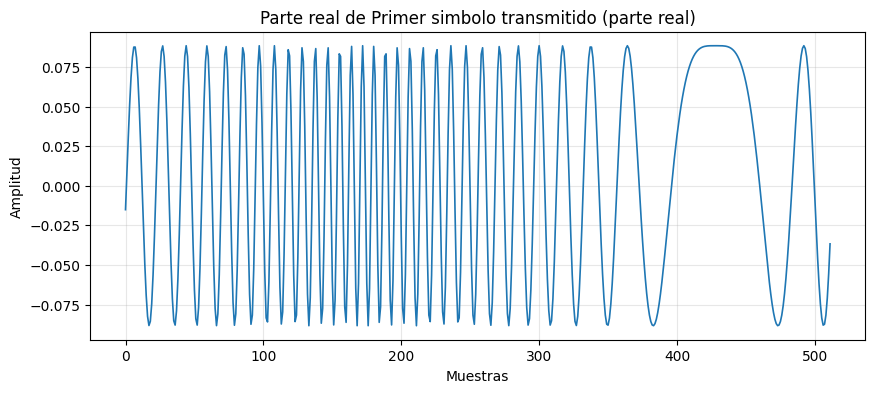

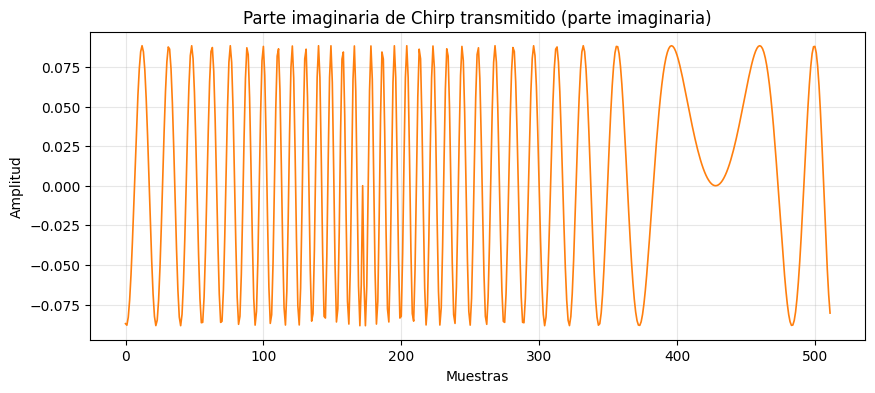

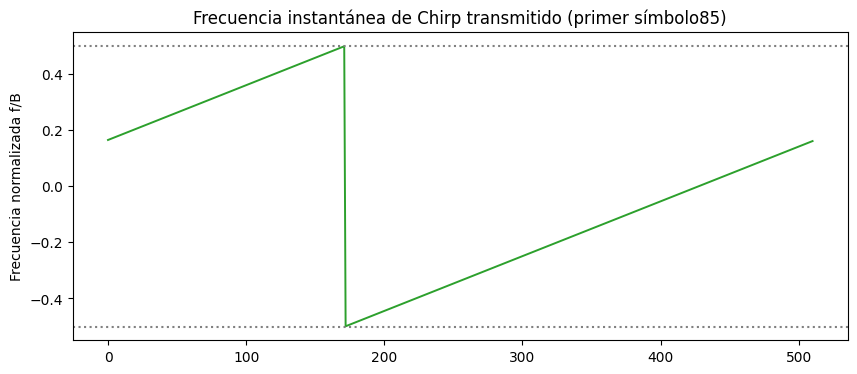

In [ ]:
bits_tx = np.random.randint(0, 2, num_simbolos * SF)   # bits aleatorios
print(f"Transmitiendo los bits: {bits_tx}")
simbolos_tx = bits_to_symbols(bits_tx, SF)             # bits -> símbolos (Módulo 1)
print(f"Símbolos a transmitir: {simbolos_tx}")
wf          = np.concatenate([simbolo_a_chirp(s, SF, OSF_sdr) for s in simbolos_tx]) #simbolos -> chirps (Módulo 2)
wf_tx       = wf * 2**14                              
print(f"Forma de onda TX: {len(wf_tx)} muestras, energía {np.sum(np.abs(wf_tx)**2):.2e}")

try: sdr.tx_destroy_buffer()
except Exception: pass
sdr.tx(wf_tx)
print(f"Transmitiendo {num_simbolos} símbolos ({len(wf)} muestras)")

plot_parte_real(wf[0:512], "Primer simbolo transmitido (parte real)")
plot_parte_imag(simbolo_a_chirp(simbolos_tx[0], SF, OSF_sdr), "Chirp transmitido (parte imaginaria)")
plot_frecuencia_instantanea(simbolo_a_chirp(simbolos_tx[0], SF, OSF_sdr),
                            "Chirp transmitido (primer símbolo" + str(simbolos_tx[0]) + ")", OSF=OSF_sdr) 

## 4. Recepción (RX)

Antes de capturar, vaciamos el buffer: el SDR puede tener muestras viejas en su cola interna, y al arrancar la transmisión hay un transitorio. Llamamos `sdr.rx()` varias veces (`range(10)`) para descartar esas capturas y recién usamos la siguiente, asegurando datos frescos y estables.

La captura se divide por `2¹⁴` para deshacer el escalado de TX (amplitudes en torno a ±1). Como la transmisión es cíclica (`tx_cyclic_buffer=True`), `rx[0]` cae en un punto arbitrario del stream; por eso alineamos por correlación (`np.correlate(rx, wf)`) para ubicar el inicio del frame y graficar un símbolo ya alineado.

Capturadas 8192 muestras | amplitud máx |rx| = 0.0056


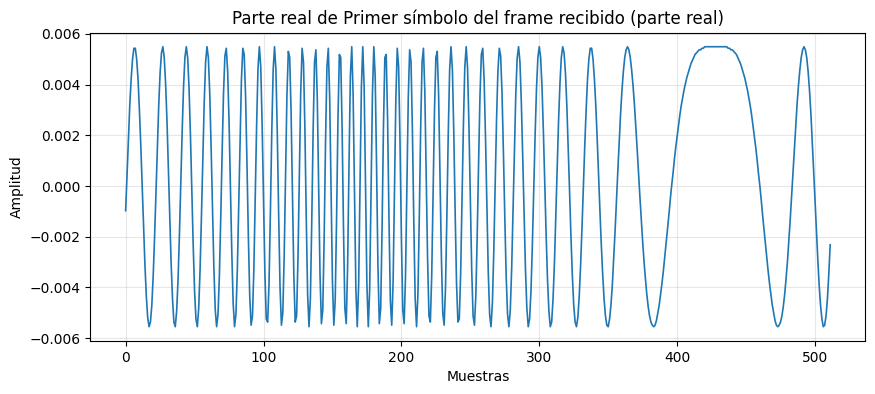

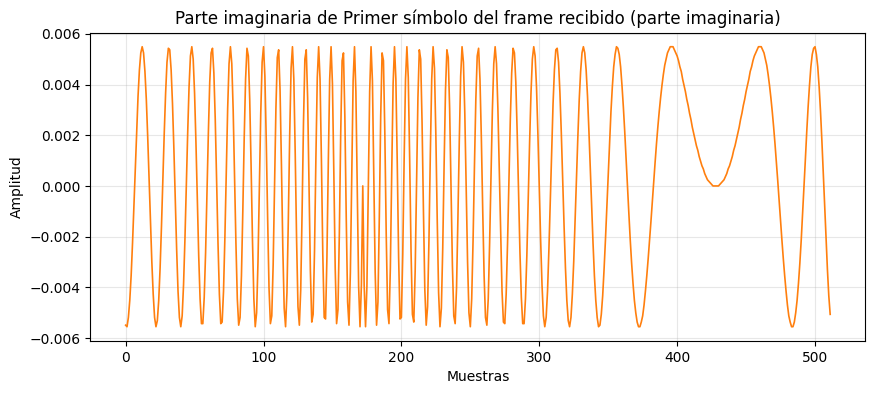

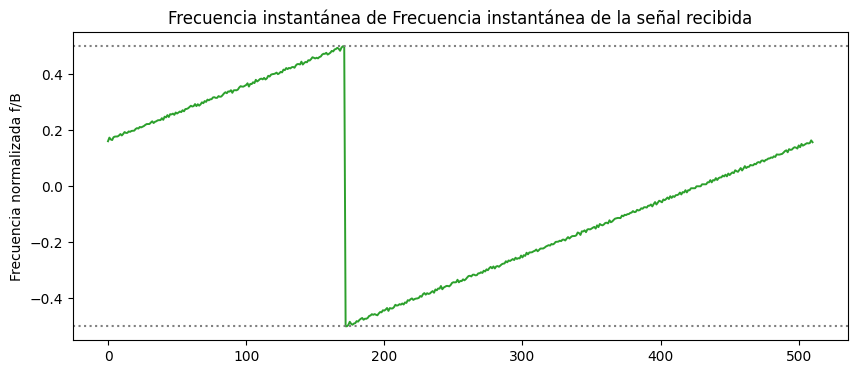

In [730]:
for _ in range(10):                
    sdr.rx()
rx = sdr.rx() / 2**14
print(f"Capturadas {len(rx)} muestras | amplitud máx |rx| = {np.max(np.abs(rx)):.4f}")

# Alinear: la correlación busca dónde arranca de verdad el frame en la captura
offset   = int(np.argmax(np.abs(np.correlate(rx, wf, mode='valid'))))
rx_frame = rx[offset : offset + len(wf)]
# --- Alternativa: alineación con offset fijo (más artesanal) ---
# En vez de correlación, se podría recortar con un offset hardcodeado a ojo:
#     rx_frame = rx[84 : 84 + len(wf)]
# Pero como la transmisión es cíclica (tx_cyclic_buffer=True), el inicio del frame
# cae en un punto distinto en cada captura -> el offset fijo se desalinea al re-ejecutar.
# Por eso usamos correlación: encuentra el inicio automáticamente en cada captura.
 
# Graficar UN símbolo del frame alineado
plot_parte_real(rx_frame[:M*OSF_sdr], "Primer símbolo del frame recibido (parte real)")
plot_parte_imag(rx_frame[:M*OSF_sdr], "Primer símbolo del frame recibido (parte imaginaria)")
plot_frecuencia_instantanea(rx_frame[:M*OSF_sdr], "Frecuencia instantánea de la señal recibida", OSF_sdr)

## 5. Demodulación y BER

Se alinea por correlación, se submuestrea a crítico (`[::OSF]`), se demodula con `chirp_a_simbolo` (Módulo 2) y se decodifica a bits con `symbols_to_bits` (Módulo 1). El down-chirp es el conjugado del chirp base.

Offset de alineación: 1204 muestras
len(rx): 8192 | len(wf): 4096 | offset: 1204 | len(rx_frame): 4096 | len(rx_crit): 1024 | necesito: 1024
Símbolos TX: [85 10 83  8 11 23 28 54]
Símbolos RX: [85 10 83  8 11 23 28 54]
SER = 0.0 | BER = 0.0


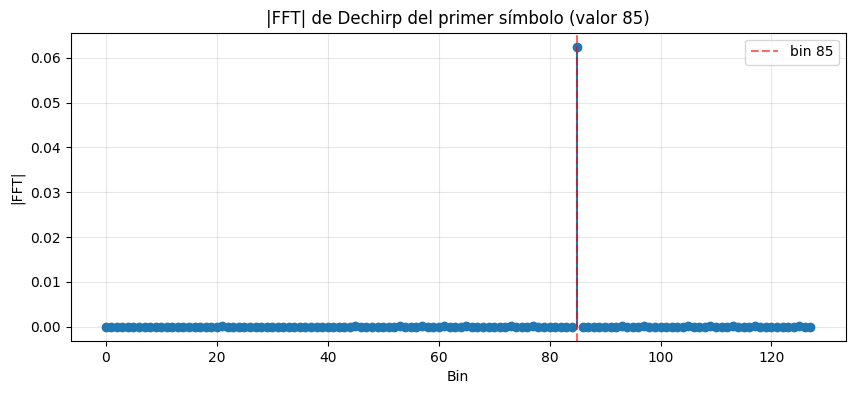

In [731]:
rx_crit     = rx_frame[::OSF_sdr]
print("len(rx):", len(rx), "| len(wf):", len(wf), "| offset:", offset,
      "| len(rx_frame):", len(rx_frame), "| len(rx_crit):", len(rx_crit),
      "| necesito:", num_simbolos * M)
simbolos_rx = np.array([chirp_a_simbolo(rx_crit[i*M:(i+1)*M], SF) for i in range(num_simbolos)])
bits_rx     = symbols_to_bits(simbolos_rx, SF)

ser = calcular_ser(simbolos_tx, simbolos_rx)
ber = calcular_ber(bits_tx, bits_rx)
print("Símbolos TX:", simbolos_tx)
print("Símbolos RX:", simbolos_rx)
print(f"SER = {ser} | BER = {ber}")

sym        = 0
seg_crit   = rx_frame[sym*M*OSF_sdr : (sym+1)*M*OSF_sdr][::OSF_sdr]
down_chirp = np.conj(simbolo_a_chirp(0, SF))   # down-chirp = conjugado del chirp base
plot_fft(seg_crit * down_chirp, f"Dechirp del primer símbolo (valor {simbolos_rx[0]})", bin_marca=int(simbolos_rx[0]))

## 6. Limpieza

Se libera el buffer TX y se sube la atenuación al máximo para no dejar el SDR transmitiendo.

In [732]:
sdr.tx_destroy_buffer()
#dr.tx_hardwaregain_chan0 = -89
print("SDR liberado.")

SDR liberado.


# Loopback de antena

Se repiten los mismos pasos que en el loopback digital, pero ahora el parámetro `Loopback` se configura para que la señal recorra la cadena de RF: sale por la antena TX y se recibe por la antena RX del mismo Pluto. La estructura (parámetros → configuración → TX → RX → demodulación) es idéntica al caso digital; lo único que cambia es el modo de loopback y, al transmitir en RF, la portadora.

In [ ]:
OSF_sdr = 8
num_simbolos = 8

Uri          = "ip:192.168.1.34"
Loopback     = 0                    # 0 = antena (señal sale por la antena) ; 2 = RF interno del chip
SamplingRate = OSF_sdr * BW
TxLOFreq     = 915e6                
TxAtten      = -10
TxRfBw       = int(SamplingRate)
tx_cyclic_buffer = True
RxLOFreq     = TxLOFreq
GainControlModes = "slow_attack"
RxHardwareGain   = 0
RxRfBw       = TxRfBw
RxBufferSize = int(2 * num_simbolos * OSF_sdr * M)

In [756]:
try:
    sdr.tx_destroy_buffer()
    del sdr
except Exception:
    pass
time.sleep(1) # hacemos esto para que el Pluto se libere y podamos reconectarnos sin problemas

sdr = adi.Pluto(Uri)

sdr.sample_rate             = int(SamplingRate)
sdr.tx_lo                   = int(TxLOFreq)
sdr.rx_lo                   = int(RxLOFreq)
sdr.tx_rf_bandwidth         = int(TxRfBw)
sdr.rx_rf_bandwidth         = int(RxRfBw)
sdr.tx_hardwaregain_chan0   = TxAtten
sdr.gain_control_mode_chan0 = GainControlModes
sdr.rx_hardwaregain_chan0   = RxHardwareGain
sdr.loopback                = Loopback
sdr.tx_cyclic_buffer        = tx_cyclic_buffer
sdr.rx_buffer_size          = RxBufferSize

print(f"Conectado a {sdr.uri} | {sdr.sample_rate/1e6:.3f} MSPS | loopback {sdr.loopback}")

Conectado a ip:192.168.1.34 | 1.000 MSPS | loopback 0


Transmitiendo 8 símbolos (8192 muestras)


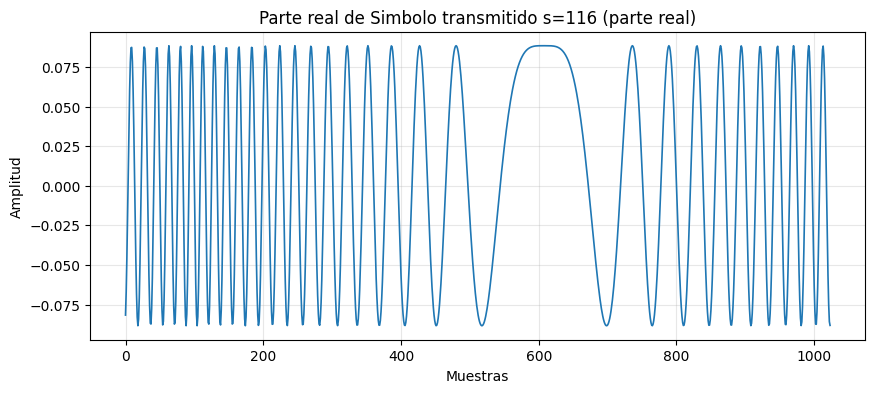

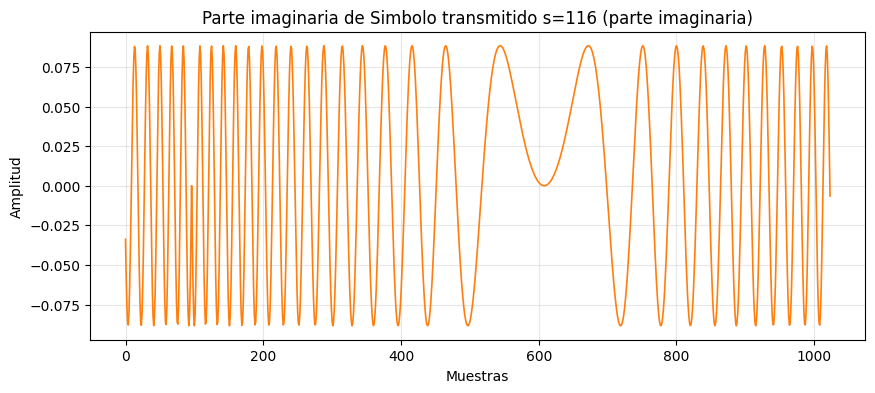

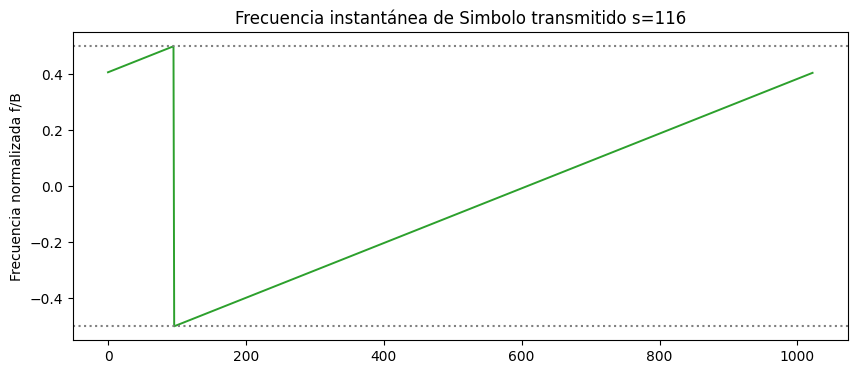

In [765]:
bits_tx     = np.random.randint(0, 2, num_simbolos * SF)
simbolos_tx = bits_to_symbols(bits_tx, SF)

wf     = np.concatenate([simbolo_a_chirp(s, SF, OSF_sdr) for s in simbolos_tx])
wf_sdr = wf * 2**14                         # escalado al rango int16 del SDR

try:
    sdr.tx_destroy_buffer()
except Exception:
    pass
sdr.tx(wf_sdr)
print(f"Transmitiendo {num_simbolos} símbolos ({len(wf)} muestras)")

plot_parte_real(wf[0:1024], "Simbolo transmitido s=" + str(simbolos_tx[0]) + " (parte real)")
plot_parte_imag(wf[0:1024], "Simbolo transmitido s=" + str(simbolos_tx[0]) + " (parte imaginaria)")
plot_frecuencia_instantanea(wf[0:1024], "Simbolo transmitido s=" + str(simbolos_tx[0]), OSF=OSF_sdr)

In [766]:
for _ in range(10):
    sdr.rx()                                # descartamos capturas viejas del buffer
rx_sdr = sdr.rx() / 2**14                   # nombre único: NO usar 'rx' (choca con los tests)
print(f"Capturadas {len(rx_sdr)} muestras | amplitud máx = {np.max(np.abs(rx_sdr)):.4f}")

Capturadas 16384 muestras | amplitud máx = 0.0422


Offset de alineación: 794 muestras
Símbolos TX: [116   9  54 102  14  71  85  16]
Símbolos RX: [116   9  54 102  14  71  85  16]
SER = 0.0 | BER = 0.0


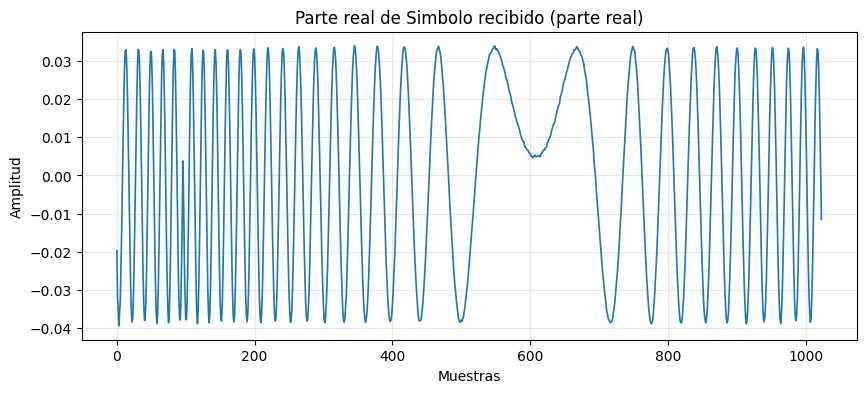

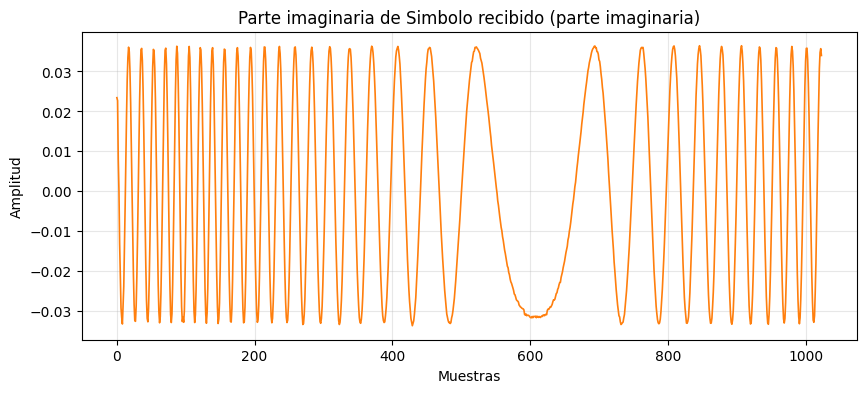

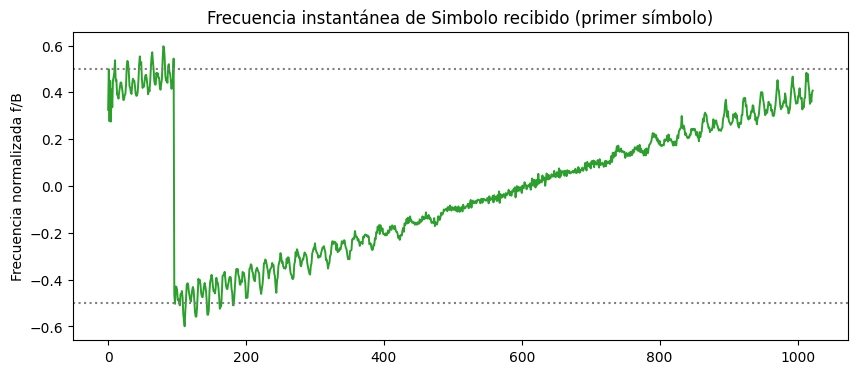

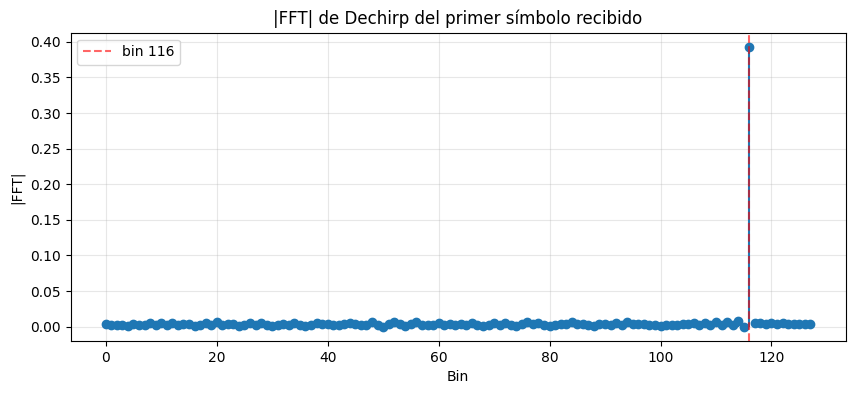

In [783]:
offset   = int(np.argmax(np.abs(np.correlate(rx_sdr, wf, mode='valid'))))
rx_frame = rx_sdr[offset : offset + len(wf)]
print(f"Offset de alineación: {offset} muestras")

rx_crit     = rx_frame[::OSF_sdr]
simbolos_rx = np.array([chirp_a_simbolo(rx_crit[i*M:(i+1)*M], SF) for i in range(num_simbolos)])
bits_rx     = symbols_to_bits(simbolos_rx, SF)

ser = calcular_ser(simbolos_tx, simbolos_rx)
ber = calcular_ber(bits_tx, bits_rx)
print(f"Símbolos TX: {simbolos_tx}")
print(f"Símbolos RX: {simbolos_rx}")
print(f"SER = {ser} | BER = {ber}")

plot_parte_real(rx_frame[:1024], "Simbolo recibido (parte real)")
plot_parte_imag(rx_frame[:1024], "Simbolo recibido (parte imaginaria)")
plot_frecuencia_instantanea(rx_frame[:1024], "Simbolo recibido (primer símbolo)", OSF=OSF_sdr)
plot_fft(rx_frame[:M*OSF_sdr][::OSF_sdr] * np.conj(simbolo_a_chirp(0, SF)), "Dechirp del primer símbolo recibido", bin_marca=int(simbolos_rx[0]))

In [738]:
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89             # apaga el TX
print("TX liberado.")

TX liberado.
